In [1]:
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import cartopy.crs as ccrs
from cartopy.util import add_cyclic_point
import cmocean
from pathlib import Path
from utils import open_exp, annual_mean, global_mean, zonal_mean, load_last_years 
from utils import regional_mean_sst, high_lat_mean_sst, global_mean_tas
from utils import annual_global_mean_tas, annual_ts, global_mean_sst
from utils import simple_regional_mean_sst, trop_mean_sst, global_toa_ts

In [2]:
plt.rcParams.update({
    "font.size": 14,
    "axes.titlesize": 16,
    "axes.labelsize": 14,
    "legend.fontsize": 12,
    "figure.titlesize": 20,
})

# Paths

In [3]:
base_path = Path("/lus/h2resw01/hpcperm/ecme3497/data-analysis/epochal/")

In [86]:
# Only exp3 needs slicing; others use full time range
exp3_path = base_path / "exp3/variables/atm/small_remapped_exp3_atm_cmip6_1m_3[2-3]*.nc"

atm_paths = {
    "3x": "XE3C/variables/atm/small_remapped_XE3C_atm_cmip6_1m_*.nc",
    "ex3": "pex3/variables/atm/small_remapped_pex3_atm_cmip6_1m_*.nc",
    "6x_X": "XE6C/variables/atm/small_remapped_XE6C_atm_cmip6_1m_*.nc",
    #"6x_J": "JE06/variables/atm/small_remapped_JE06_atm_cmip6_1m_*.nc",
}


In [87]:
# Only exp3 needs slicing; others use full time range
exp3_path_oce = base_path / "exp3/variables/oce/small_remapped_exp3_oce_1m_T_3[2-3]*.nc"

oce_paths = {
    "3x": "XE3C/variables/oce/small_remapped_XE3C_oce_1m_T_*.nc",
    "ex3": "pex3/variables/oce/small_remapped_pex3_oce_1m_T_*.nc",
    "6x_X": "XE6C/variables/oce/small_remapped_XE6C_oce_1m_T_*.nc",
    #"6x_J": "JE06/variables/oce/small_remapped_JE06_oce_1m_T_*.nc",
}

# Load data

In [88]:
# Slice only exp3
exp3 = xr.open_mfdataset(str(exp3_path), combine='by_coords')
exp3 = exp3.sel(time_counter=slice("3249-01-01", "3349-12-31"))

exp3_oce = xr.open_mfdataset(str(exp3_path_oce), combine='by_coords')
exp3_oce = exp3_oce.sel(time_counter=slice("3249-01-01", "3349-12-31"))

# Load other experiments lazily
atm = {k: load_last_years(base_path, p, nyears=100) for k, p in atm_paths.items()}

# Load other experiments lazily
oce = {k: load_last_years(base_path, p, nyears=100) for k, p in oce_paths.items()}


/etc/ecmwf/ssd/ssd1/tmpdirs/ecme3497.2874669.20260721_124458.435/ipykernel_4041031/1203475380.py:2: SerializationWarning: Unable to decode time axis into full numpy.datetime64[ns] objects, continuing using cftime.datetime objects instead, reason: dates out of range. To silence this warning use a coarser resolution 'time_unit' or specify 'use_cftime=True'.
  exp3 = xr.open_mfdataset(str(exp3_path), combine='by_coords')
/etc/ecmwf/ssd/ssd1/tmpdirs/ecme3497.2874669.20260721_124458.435/ipykernel_4041031/1203475380.py:2: SerializationWarning: Unable to decode time axis into full numpy.datetime64[ns] objects, continuing using cftime.datetime objects instead, reason: dates out of range. To silence this warning use a coarser resolution 'time_unit' or specify 'use_cftime=True'.
  exp3 = xr.open_mfdataset(str(exp3_path), combine='by_coords')
/etc/ecmwf/ssd/ssd1/tmpdirs/ecme3497.2874669.20260721_124458.435/ipykernel_4041031/1203475380.py:2: SerializationWarning: Unable to decode time axis into fu

XE3C/variables/atm/small_remapped_XE3C_atm_cmip6_1m_*.nc: 1800-1899 (100 files)
Dropping incomplete year 1806
pex3/variables/atm/small_remapped_pex3_atm_cmip6_1m_*.nc: 1706-1805 (100 files)
XE6C/variables/atm/small_remapped_XE6C_atm_cmip6_1m_*.nc: 1800-1899 (100 files)
XE3C/variables/oce/small_remapped_XE3C_oce_1m_T_*.nc: 1800-1899 (100 files)
Dropping incomplete year 1806
pex3/variables/oce/small_remapped_pex3_oce_1m_T_*.nc: 1706-1805 (100 files)
XE6C/variables/oce/small_remapped_XE6C_oce_1m_T_*.nc: 1800-1899 (100 files)


In [89]:
exp_order = ["pi", "ex3", "3x", "6x_X"]

# Build TAS climatologies

In [91]:
tas = {}

# exp3 (PI control)
tas["pi"] = annual_mean(exp3["tas"]) - 273.15

# Other experiments
for k, ds in atm.items():
    tas[k] = annual_mean(ds["tas"]) - 273.15


# Anomalies relative to PI zonal mean

In [92]:
tas_pi_zonal = zonal_mean(tas["pi"])

tas_anom = {
    k: tas[k] - tas_pi_zonal
    for k in ["ex3", "3x", "6x_X"]
}


# Figure 1 - Climatology + anomalies

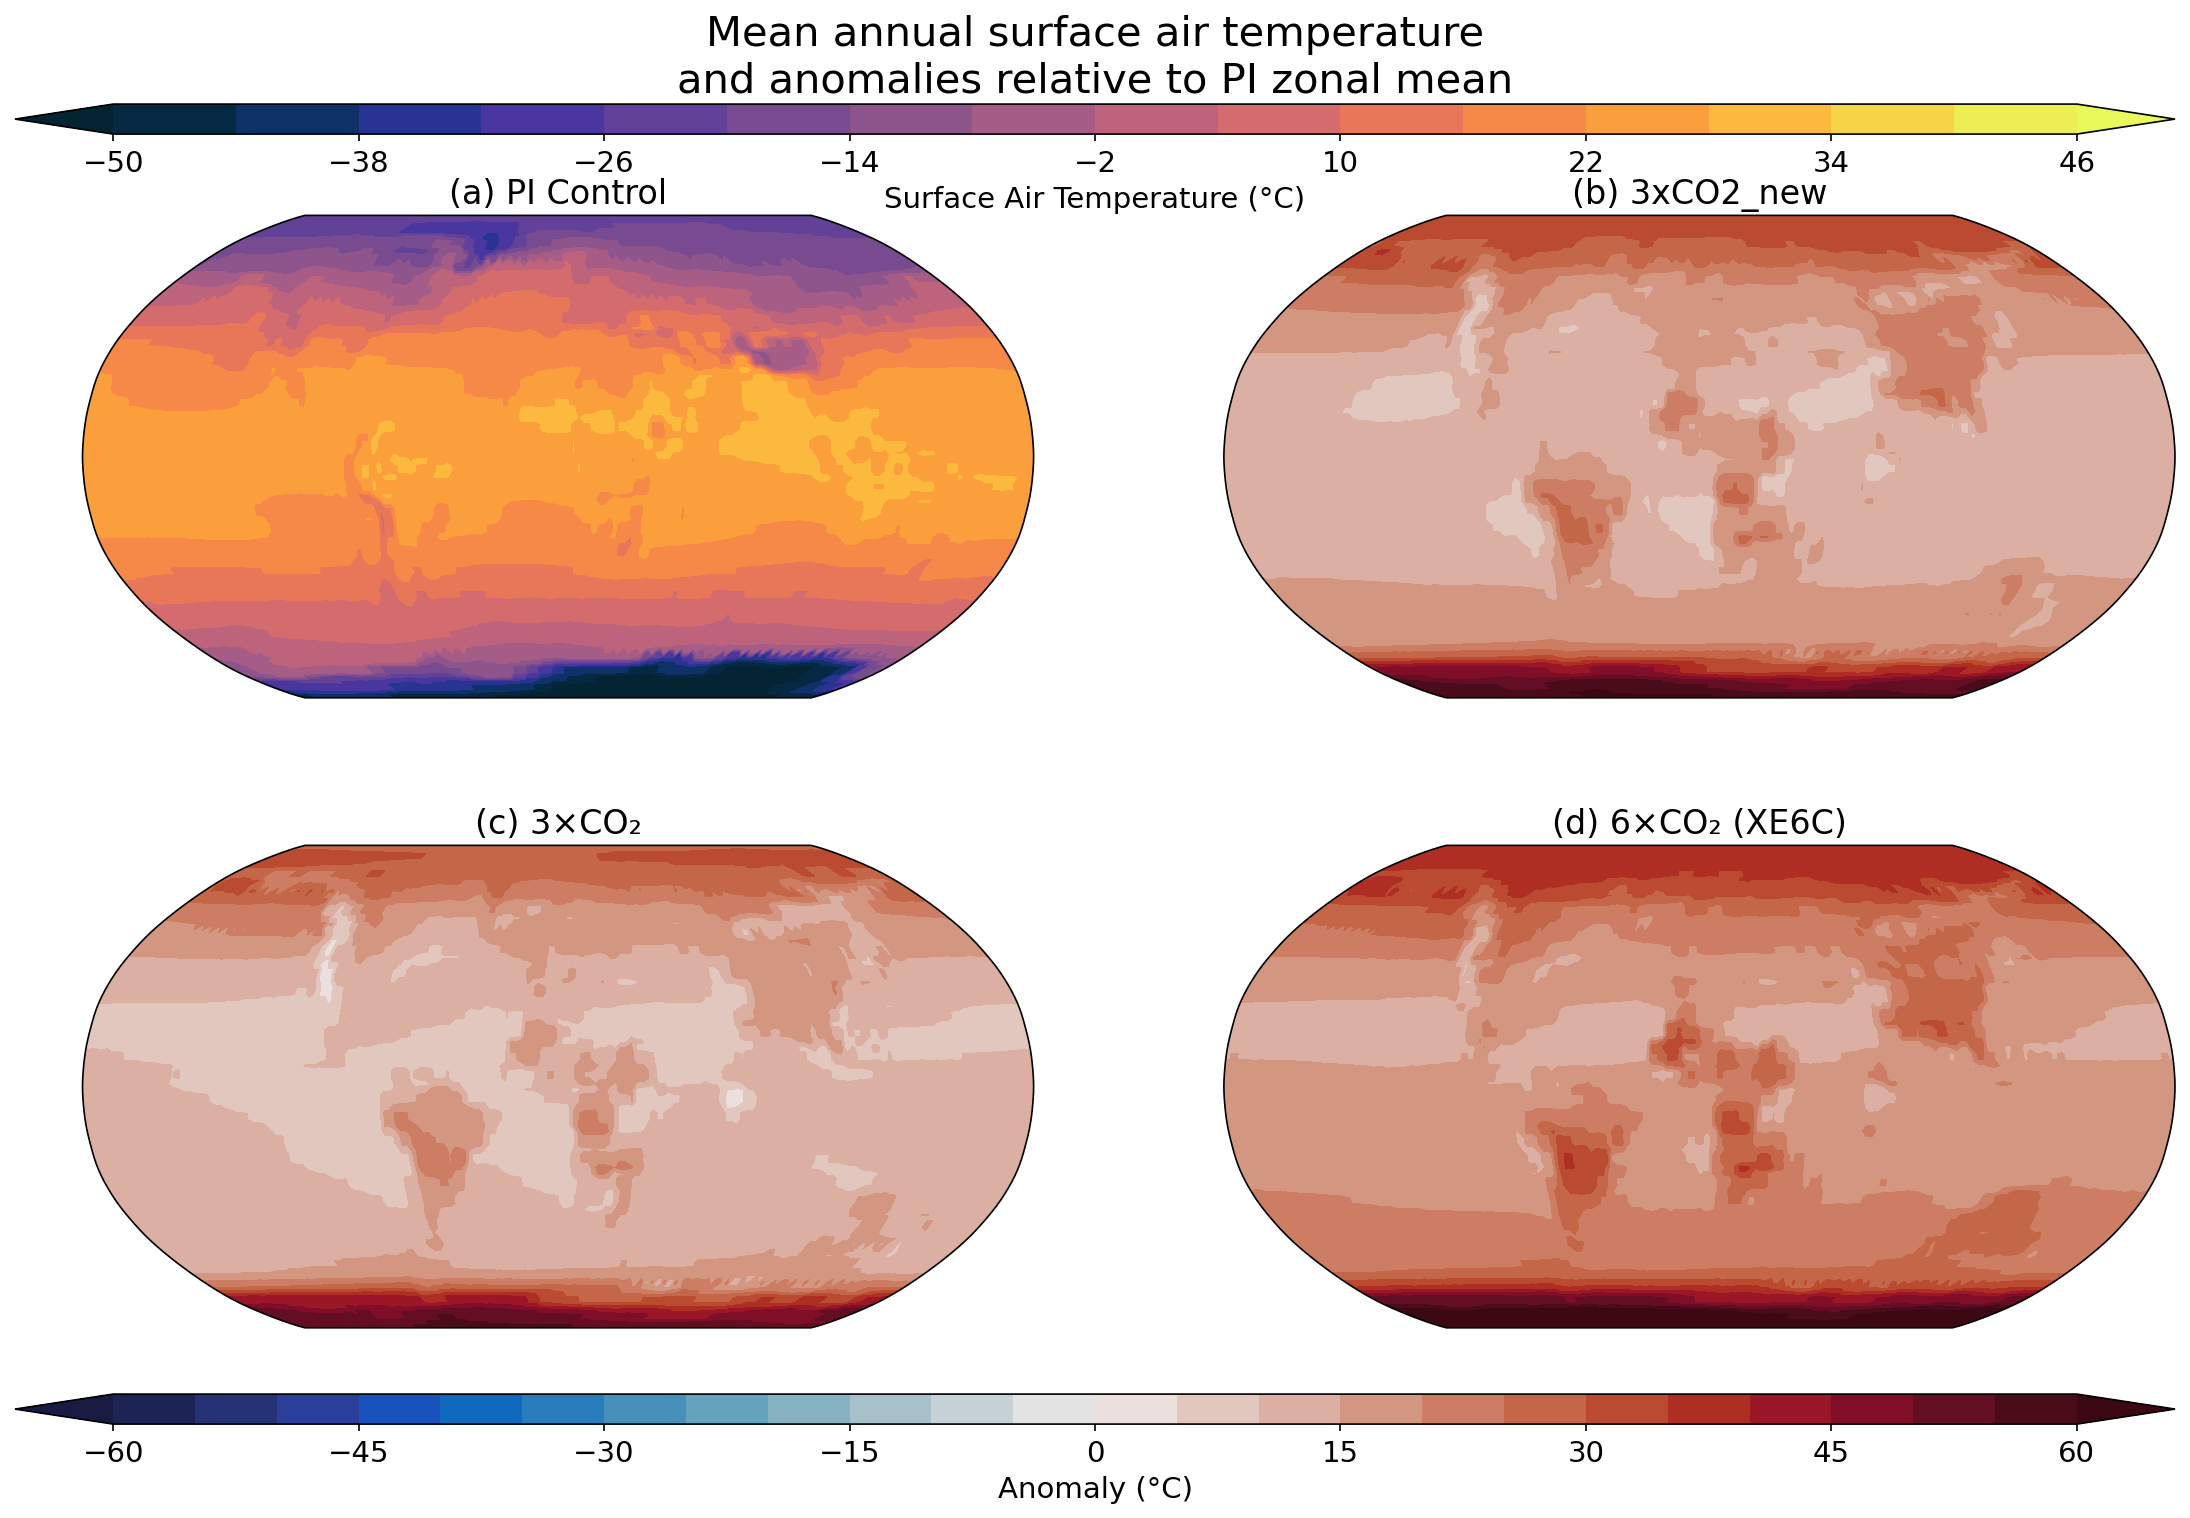

In [93]:
levels_abs = np.arange(-50, 50.5, 6)
levels_anom = np.arange(-60, 60.5, 5)

cmap_abs = cmocean.cm.thermal
cmap_anom = cmocean.cm.balance

fig, axes = plt.subplots(
    2, 2, figsize=(18, 10), dpi=150,
    subplot_kw={"projection": ccrs.Robinson()}
)
axs = axes.flatten()

pi_cyc, lon_cyc = add_cyclic_point(tas["pi"], coord=tas["pi"].lon)

cf0 = axs[0].contourf(
    lon_cyc, tas["pi"].lat, pi_cyc,
    levels=levels_abs, cmap=cmap_abs,
    transform=ccrs.PlateCarree(), extend="both"
)
axs[0].set_title("(a) PI Control")
axs[0].set_global()

titles = {"ex3": "(b) 3xCO2_new", "3x": "(c) 3×CO₂", "6x_X": "(d) 6×CO₂ (XE6C)"}

for i, k in enumerate(["ex3", "3x", "6x_X"], start=1):
    data_cyc, _ = add_cyclic_point(tas_anom[k], coord=tas_anom[k].lon)

    cf = axs[i].contourf(
        lon_cyc, tas_anom[k].lat, data_cyc,
        levels=levels_anom, cmap=cmap_anom,
        transform=ccrs.PlateCarree(), extend="both"
    )
    axs[i].set_title(titles[k])
    axs[i].set_global()


cax_abs = fig.add_axes([0.1, 0.92, 0.8, 0.02])
fig.colorbar(cf0, cax=cax_abs, orientation="horizontal",
             label="Surface Air Temperature (°C)")

cax_anom = fig.add_axes([0.1, 0.06, 0.8, 0.02])
fig.colorbar(cf, cax=cax_anom, orientation="horizontal",
             label="Anomaly (°C)")

fig.suptitle(
    "Mean annual surface air temperature\nand anomalies relative to PI zonal mean",
    y=1.0
)

plt.savefig("tas_maps.png", bbox_inches="tight")
plt.show()

# Global mean Surface air temperature vs CO2

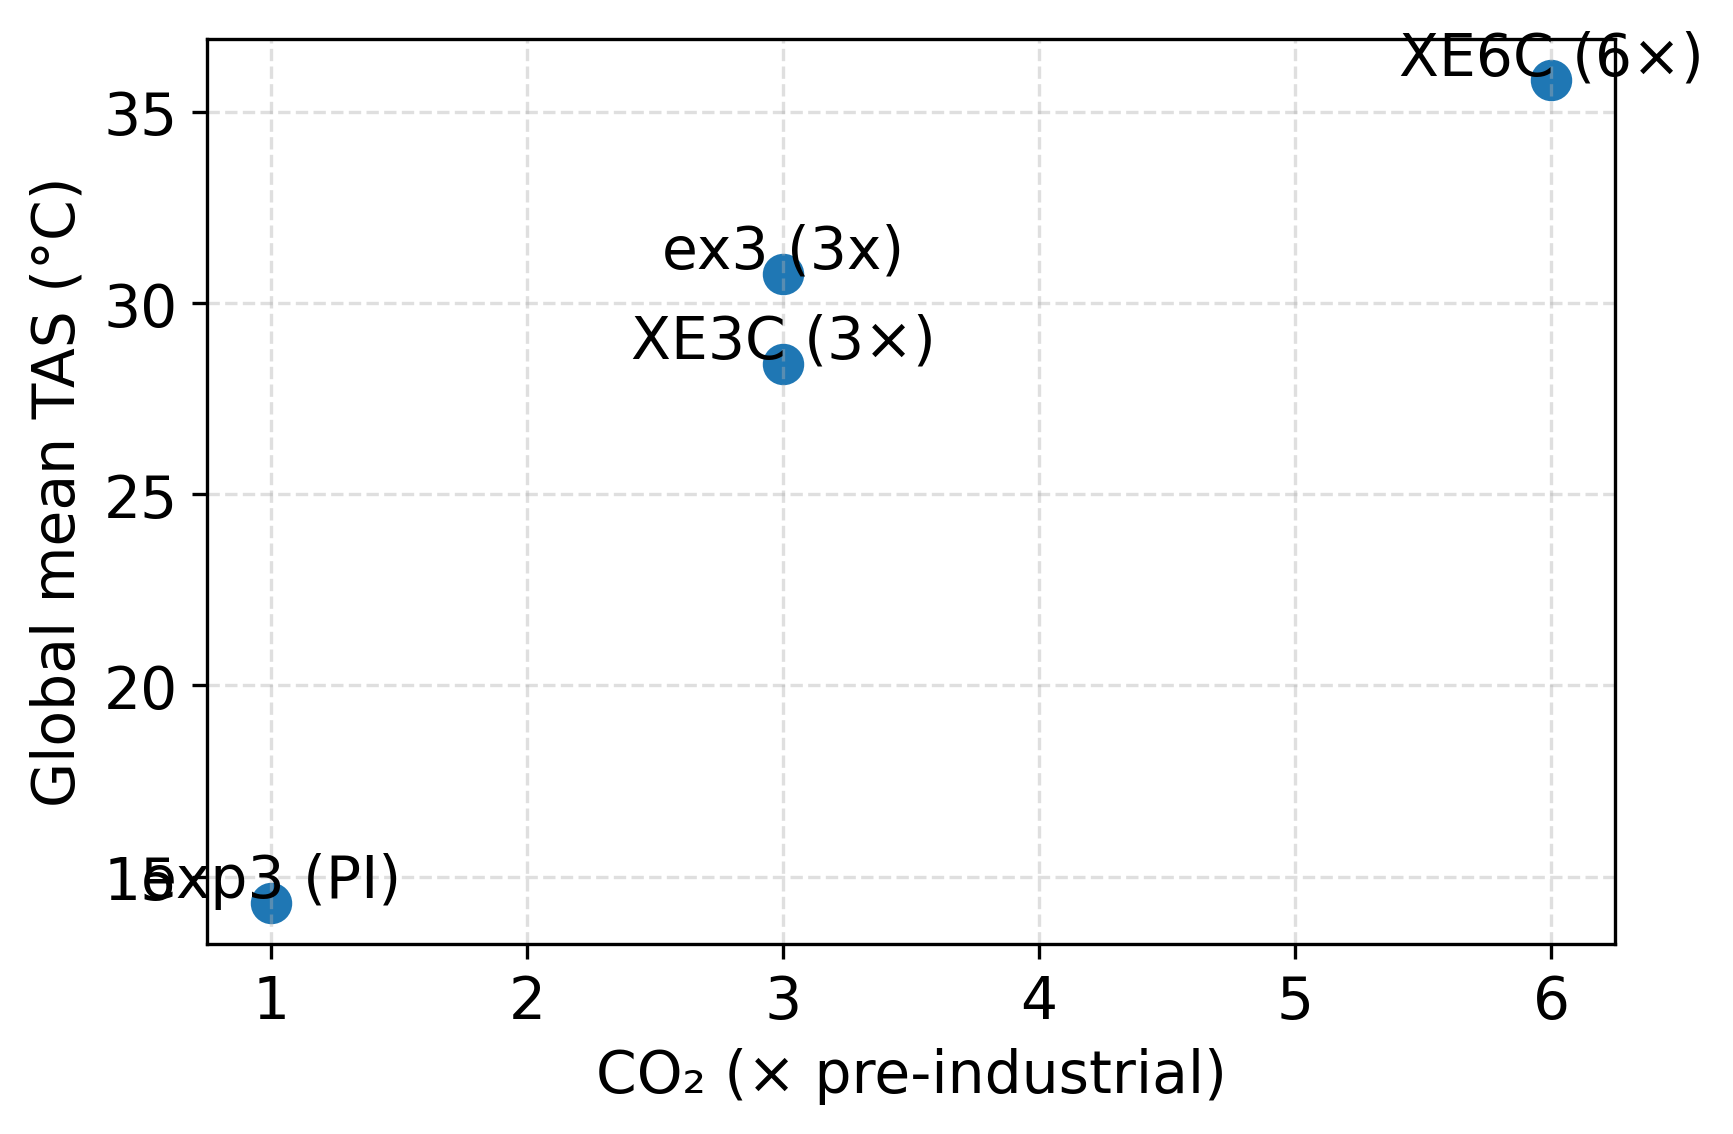

In [94]:

T = {k: global_mean(v).values for k, v in tas.items()}

co2 = [1, 3, 3, 6]
labels = ["exp3 (PI)", "ex3 (3x)", "XE3C (3×)", "XE6C (6×)"]
vals = [T["pi"], T["ex3"], T["3x"], T["6x_X"]]

plt.figure(figsize=(6, 4), dpi=300)
plt.scatter(co2, vals, s=80)

for x, y, lab in zip(co2, vals, labels):
    plt.text(x, y + 0.15, lab, ha="center")

plt.xlabel("CO₂ (× pre-industrial)")
plt.ylabel("Global mean TAS (°C)")
plt.grid(True, linestyle="--", alpha=0.4)
plt.tight_layout()
plt.savefig("tas_global_vs_co2.png")
plt.show()


# Surface air temperature zonal anomalies

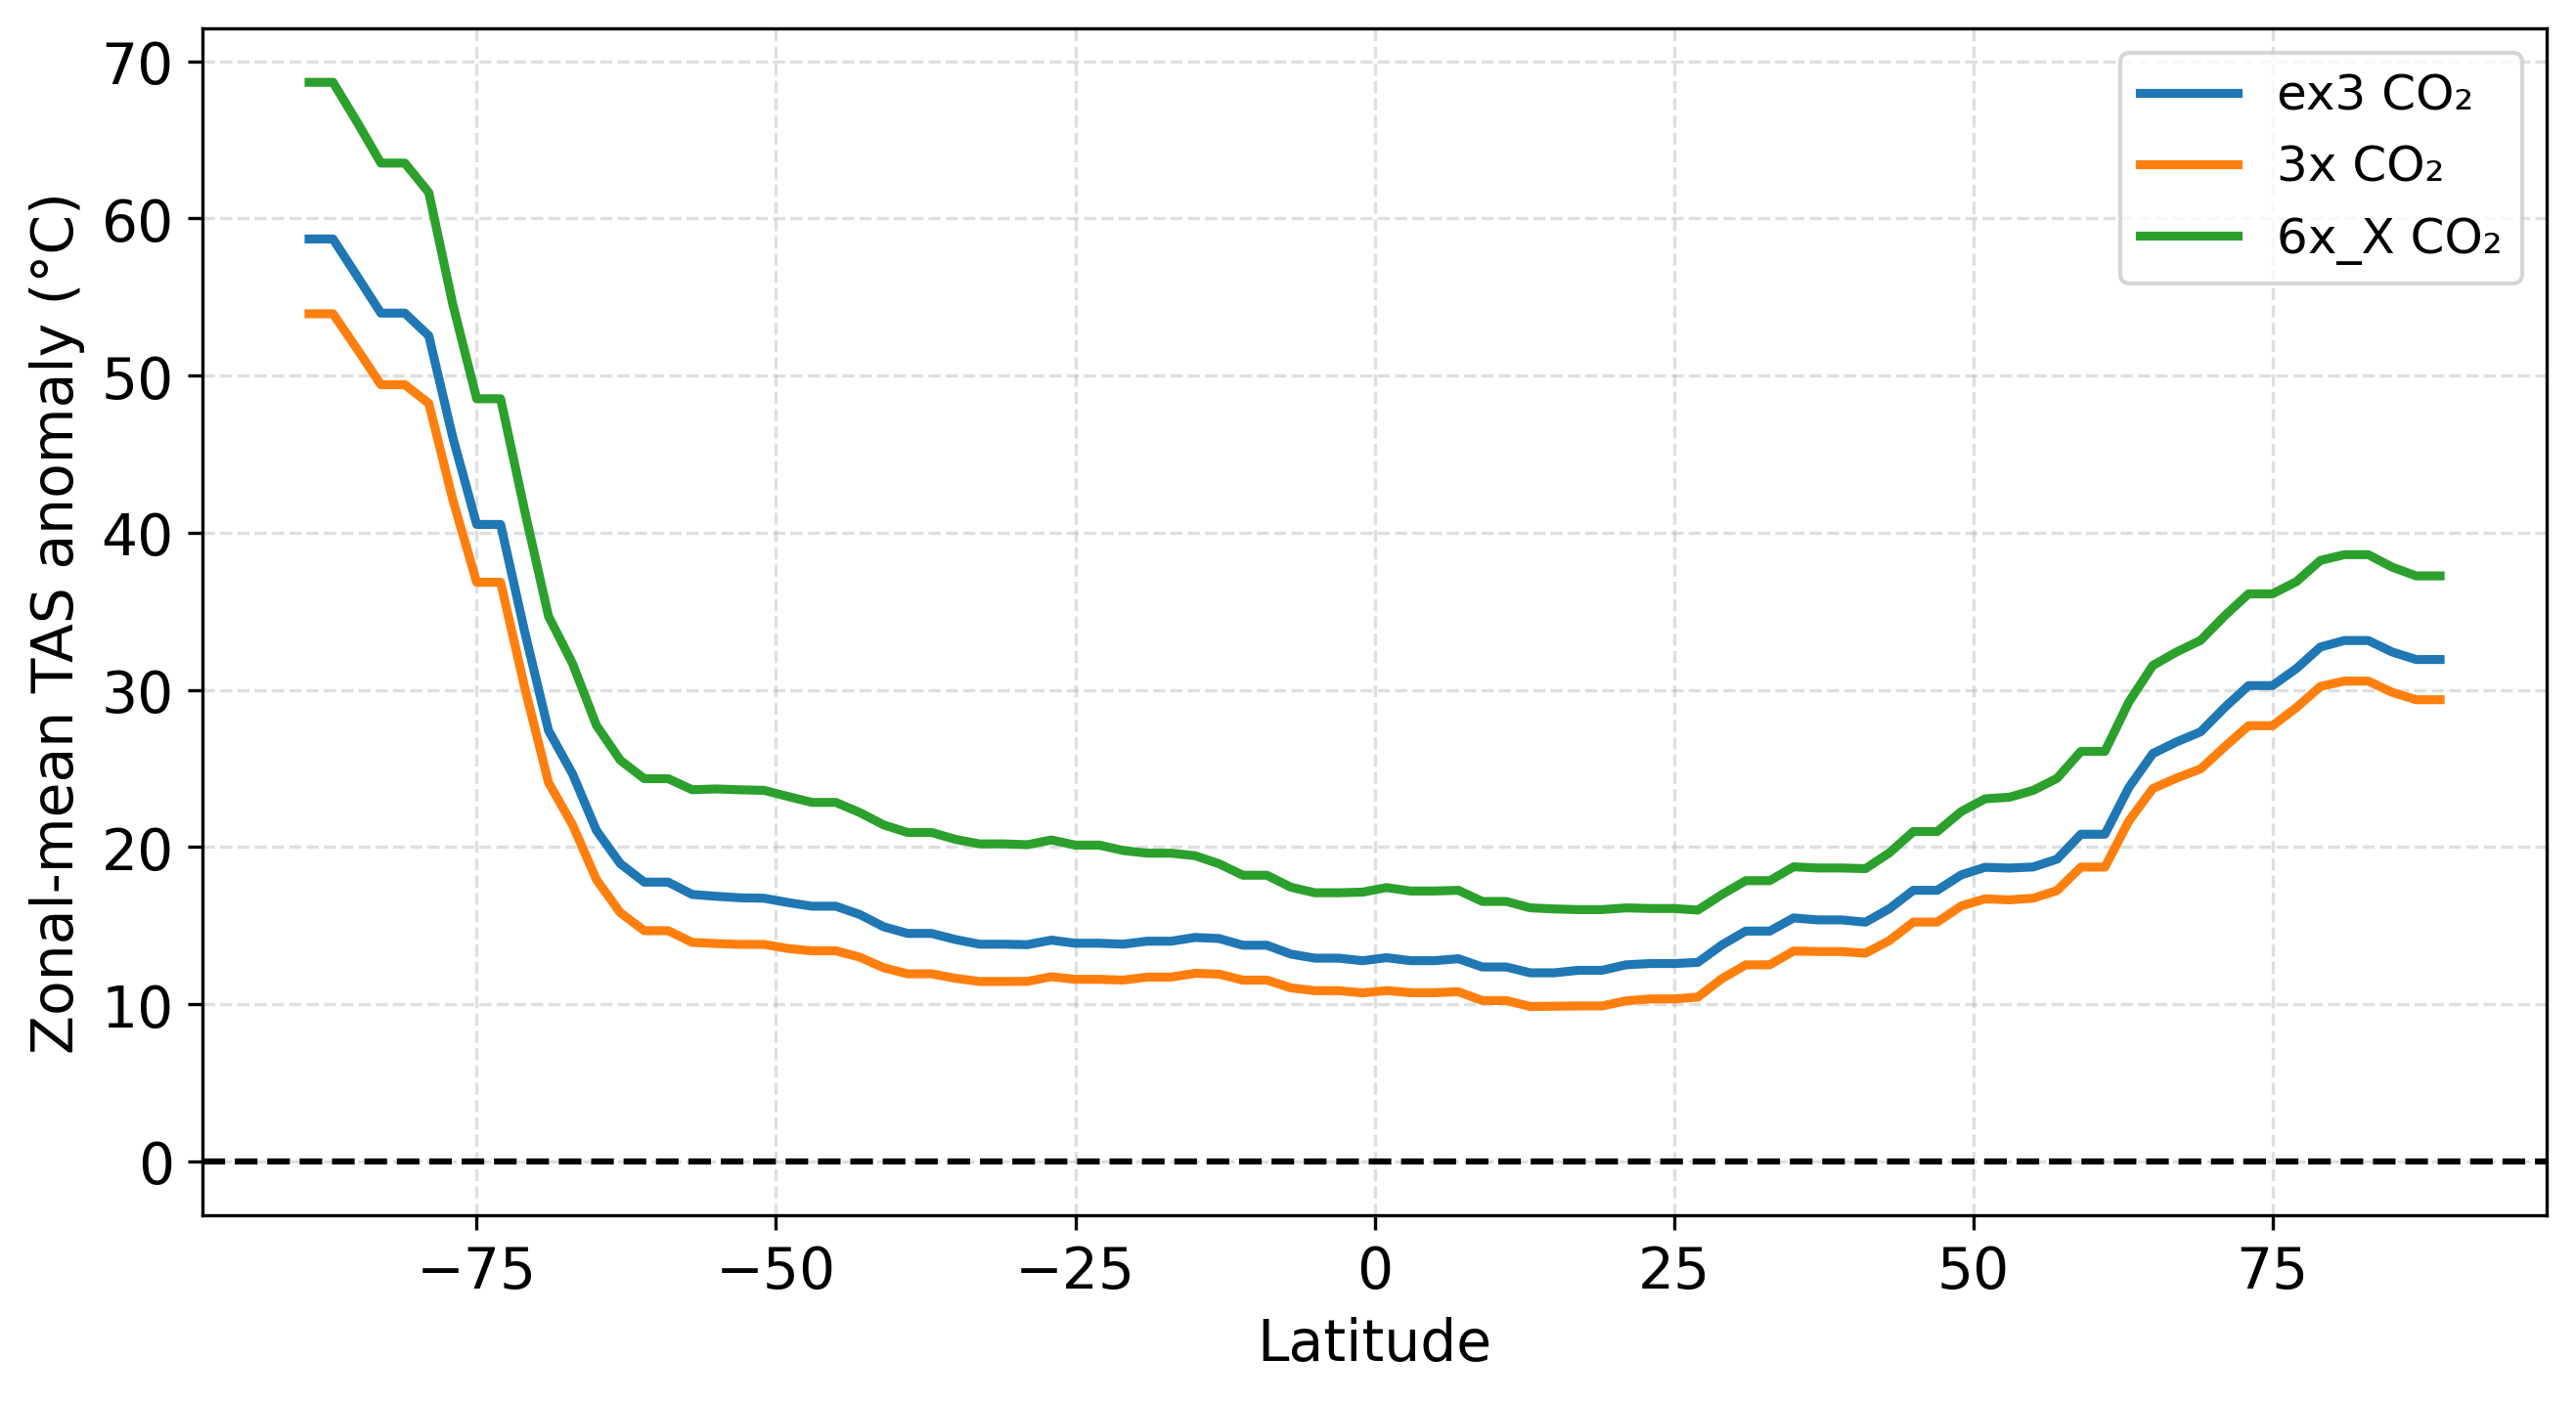

In [95]:
plt.figure(figsize=(9,5), dpi=300)
for k in ["ex3", "3x", "6x_X"]:
    plt.plot(tas["pi"].lat, tas_anom[k].mean("lon"), linewidth=2.2, label=f"{k} CO₂")
plt.axhline(0, color="k", linestyle="--")
plt.xlabel("Latitude")
plt.ylabel("Zonal-mean TAS anomaly (°C)")
plt.legend()
plt.grid(True, linestyle="--", alpha=0.4)
plt.tight_layout()
plt.savefig("tas_zonal_anom.png")
plt.show()


# Global mean TAS & ΔT table

In [96]:
# Compute global means
T = {k: global_mean(v).values for k, v in tas.items()}

# ΔT relative to PI control
delta_T = {k: T[k] - T["pi"] for k in ["ex3", "3x", "6x_X"]}

# ΔT relative to PI-P control
#delta_T_P = {k: T[k] - T["piP"] for k in ["3x", "6x", "6x"]}

# --- Print table in notebook ---
print("\nCO₂ ×   Global mean TAS (°C)")
print("-----------------------------")
print(f"exp3 (PI)  : {T['pi']:.2f}")
#print(f"XPPI (PIP)  : {T['piP']:.2f}")
print(f"pex3 (3×)  : {T['ex3']:.2f}")
print(f"XE3C (3×)  : {T['3x']:.2f}")
print(f"XE6C (6×)  : {T['6x_X']:.2f}")
#print(f"JE06 (6×)  : {T['6x_J']:.2f}")

print("\nΔT relative to exp3 (°C)")
print("-------------------------")
print(f"pex3 – exp3 : {delta_T['ex3']:+.2f}")
print(f"XE3C – exp3 : {delta_T['3x']:+.2f}")
print(f"XE6C – exp3 : {delta_T['6x_X']:+.2f}")
#print(f"JE06 – exp3 : {delta_T['6x_J']:+.2f}")

#print("\nΔT relative to XPPI (°C)")
#print("-------------------------")
#print(f"XEPI – XPPI : {delta_T_P['1x']:+.2f}")
#print(f"XE3C – XPPI : {delta_T_P['3x']:+.2f}")
#print(f"XE6C – XPPI : {delta_T_P['6x']:+.2f}")




CO₂ ×   Global mean TAS (°C)
-----------------------------
exp3 (PI)  : 14.31
pex3 (3×)  : 30.78
XE3C (3×)  : 28.41
XE6C (6×)  : 35.84

ΔT relative to exp3 (°C)
-------------------------
pex3 – exp3 : +16.47
XE3C – exp3 : +14.11
XE6C – exp3 : +21.54


In [97]:
co2_ratio = 3

ECS = delta_T["ex3"]  / np.log2(co2_ratio)

print(ECS)

10.390385934324028


In [98]:
import numpy as np

# CO2 concentrations
co2 = np.array([1, 3, 3, 6])

# Corresponding global mean temperatures (°C)
temps = np.array([T["pi"], T["ex3"], T["3x"], T["6x_X"]])  # replace with your values

# Convert CO2 to log2 scale
x = np.log2(co2)

# Linear regression using numpy.polyfit
slope, intercept = np.polyfit(x, temps, 1)

ECS = slope  # slope is temperature change per CO2 doubling

print("Estimated ECS (°C per CO2 doubling):", ECS)


Estimated ECS (°C per CO2 doubling): 8.508933498973962


In [99]:
tas_ts = {}

# exp3 (PI control)
tas_ts["pi"] = annual_global_mean_tas(exp3)

# Other experiments
for k, ds in atm.items():
    tas_ts[k] = annual_global_mean_tas(ds)

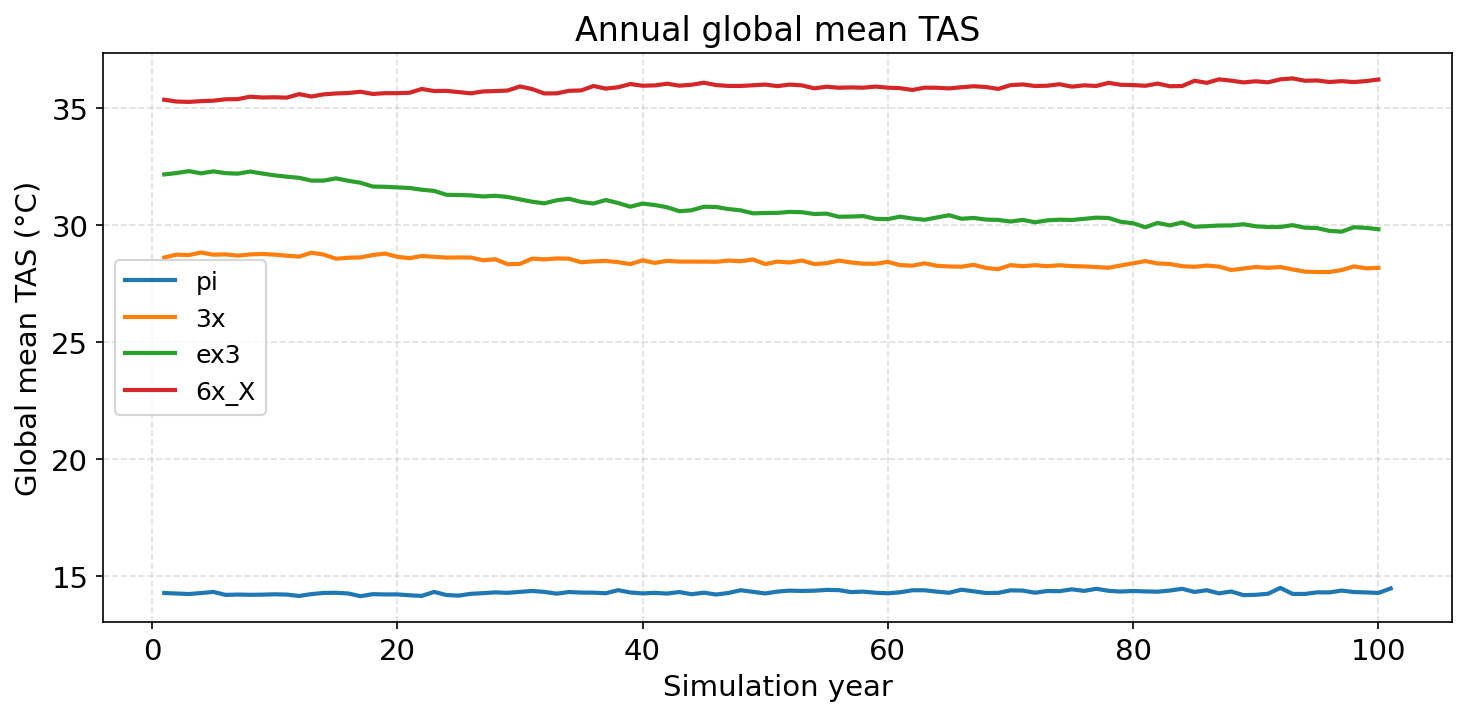

In [100]:
plt.figure(figsize=(10, 5), dpi=150)

for k, da in tas_ts.items():
    years = np.arange(1, len(da) + 1)
    plt.plot(years, da.values, label=k, linewidth=2)

plt.xlabel("Simulation year")
plt.ylabel("Global mean TAS (°C)")
plt.title("Annual global mean TAS")
plt.grid(True, linestyle="--", alpha=0.4)
plt.legend()
plt.tight_layout()
plt.show()



In [101]:
tas_anom_global = {
    k: tas[k] - tas["pi"]
    for k in ["ex3", "3x", "6x_X"]
}

In [102]:
def polar_mean(da):
    polar = da.where(np.abs(da.lat) >= 60, drop=True)
    weights = np.cos(np.deg2rad(polar.lat))
    weights = weights / weights.mean()
    return (polar * weights).mean(("lat","lon"))

In [103]:
polar_warming = {
    k: polar_mean(tas_anom_global[k]).values
    for k in ["ex3", "3x", "6x_X"]
}

In [104]:
polar_amp = {
    k: polar_warming[k] / delta_T[k]
    for k in ["ex3","3x","6x_X"]
}

print("\nPolar Amplification Factor")
print("---------------------------")
for k,v in polar_amp.items():
    print(f"{k} CO2 : {v:.2f}")


Polar Amplification Factor
---------------------------
ex3 CO2 : 1.81
3x CO2 : 1.91
6x_X CO2 : 1.69


# TOA

In [105]:
toa_ts = {}

# exp3 (PI control)
toa_ts["pi"] = global_toa_ts(exp3)

# other experiments
for k, ds in atm.items():
    toa_ts[k] = global_toa_ts(ds)

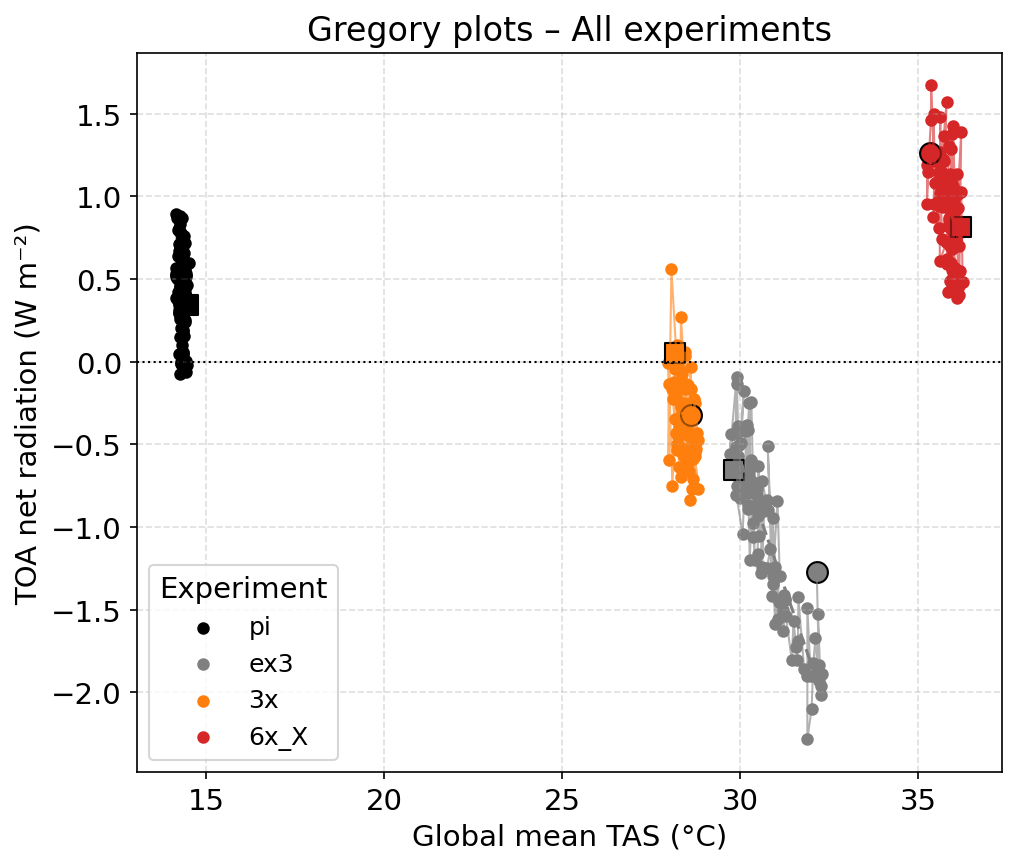

In [106]:
colors = {
    "pi":  "black",
    #"piPL": "tab:pink",
    "ex3": "gray",
    #"1x":  "tab:blue",
    "3x":  "tab:orange",
    "6x_X":  "tab:red",
    #"6x":  "tab:blue",
}

plt.figure(figsize=(7,6), dpi=150)

for exp in exp_order:

    tas_series = tas_ts[exp]
    toa_series = toa_ts[exp]

    # Make sure time matches
    tas_series, toa_series = xr.align(tas_series, toa_series)

    x = tas_series.values
    y = toa_series.values

    # ---- regression ----
    coef = np.polyfit(x, y, 1)
    slope = coef[0]
    intercept = coef[1]

    x_fit = np.linspace(x.min(), x.max(), 100)
    y_fit = slope * x_fit + intercept

    # ---- evolution line ----
    plt.plot(x, y, color=colors[exp], alpha=0.6, linewidth=1)

    # ---- scatter ----
    plt.scatter(x, y, color=colors[exp], s=25, label=exp)

    # ---- first & last year ----
    plt.scatter(x[0], y[0], color=colors[exp], s=100, 
                marker="o", edgecolor="k")
    plt.scatter(x[-1], y[-1], color=colors[exp], s=100, 
                marker="s", edgecolor="k")

    # ---- regression line ----
    plt.plot(x_fit, y_fit, color=colors[exp], linestyle="--")

# zero TOA line
plt.axhline(0, color="k", linestyle=":", linewidth=1)

plt.xlabel("Global mean TAS (°C)")
plt.ylabel("TOA net radiation (W m⁻²)")
plt.title("Gregory plots – All experiments")

plt.grid(True, linestyle="--", alpha=0.4)
plt.legend(title="Experiment")
plt.tight_layout()
plt.show()

# Precipitation

In [107]:
def prepare_pr(da):
    """Convert kg m-2 s-1 → mm/day and compute annual mean."""
    da = da * 86400.0
    da.attrs["units"] = "mm/day"
    return annual_mean(da)

In [108]:
pr = {}

# piControl
pr["pi"] = prepare_pr(exp3["pr"])

# perturbation experiments
for k, ds in atm.items():
    pr[k] = prepare_pr(ds["pr"])


In [109]:
pr_pi_zonal = zonal_mean(pr["pi"])
pi_2d = {k: pr_pi_zonal.broadcast_like(v) for k, v in pr.items() if k != "pi"}
pr_anom = {k: pr[k] - pi_2d[k] for k in pi_2d}
pr_anom_zonal = {k: v.mean("lon") for k, v in pr_anom.items()}


In [110]:
pr_global = {k: global_mean(v) for k, v in pr.items()}

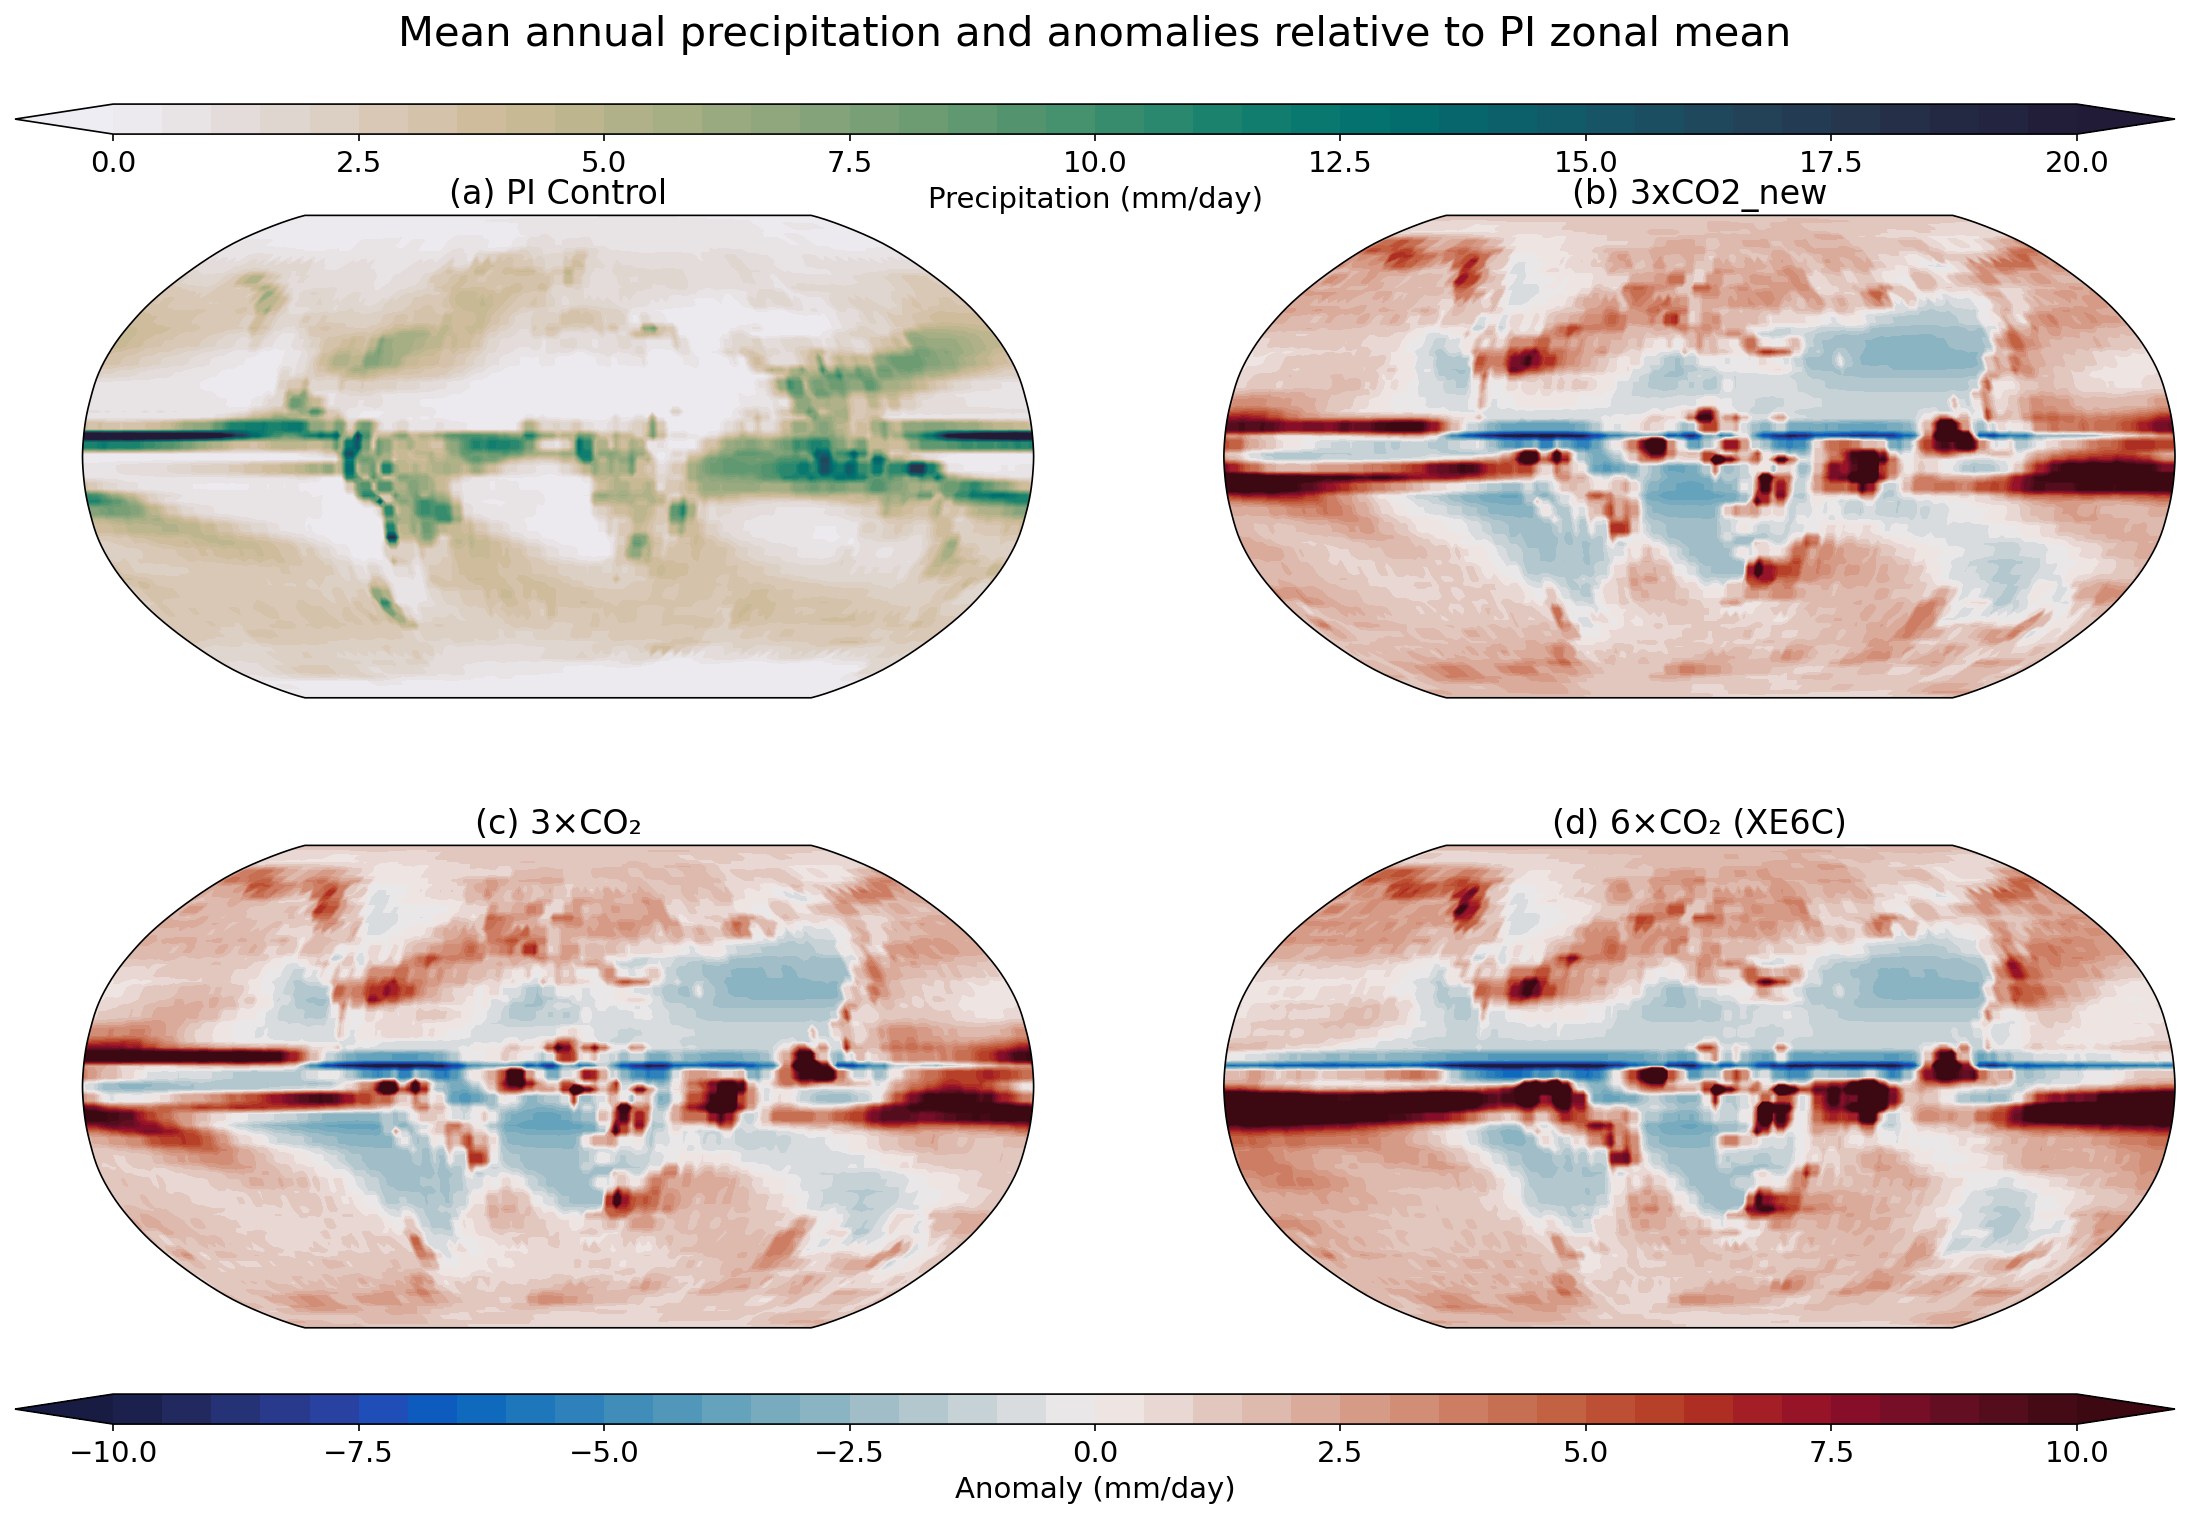

In [111]:
levels_abs = np.arange(0, 20.5, 0.5)        # absolute precipitation
levels_anom = np.arange(-10, 10.5, 0.5)      # anomalies

cmap_abs = cmocean.cm.rain
cmap_anom = cmocean.cm.balance

fig, axes = plt.subplots(
    2, 2, figsize=(18, 10), dpi=150,
    subplot_kw={"projection": ccrs.Robinson()}
)
axs = axes.flatten()

pi_cyc, lon_cyc = add_cyclic_point(pr["pi"], coord=pr["pi"].lon)

cf0 = axs[0].contourf(
    lon_cyc, pr["pi"].lat, pi_cyc,
    levels=levels_abs, cmap=cmap_abs,
    transform=ccrs.PlateCarree(), extend="both"
)
axs[0].set_title("(a) PI Control")
axs[0].set_global()

titles = {"ex3": "(b) 3xCO2_new", "3x": "(c) 3×CO₂", "6x_X": "(d) 6×CO₂ (XE6C)"}
#titles = {"1x": "(b) 1×CO2", "3x": "(c) 3×CO₂", "6x": "(d) 6×CO₂"}

for i, k in enumerate(["ex3", "3x", "6x_X"], start=1):
    data_cyc, _ = add_cyclic_point(pr_anom[k], coord=pr_anom[k].lon)

    cf = axs[i].contourf(
        lon_cyc, pr_anom[k].lat, data_cyc,
        levels=levels_anom, cmap=cmap_anom,
        transform=ccrs.PlateCarree(), extend="both"
    )
    axs[i].set_title(titles[k])
    axs[i].set_global()


cax_abs = fig.add_axes([0.1, 0.92, 0.8, 0.02])
fig.colorbar(cf0, cax=cax_abs, orientation="horizontal",
             label="Precipitation (mm/day)")

cax_anom = fig.add_axes([0.1, 0.06, 0.8, 0.02])
fig.colorbar(cf, cax=cax_anom, orientation="horizontal",
             label="Anomaly (mm/day)")

fig.suptitle(
    "Mean annual precipitation and anomalies relative to PI zonal mean",
    y=1.0
)

plt.savefig("tas_maps.png", bbox_inches="tight")
plt.show()

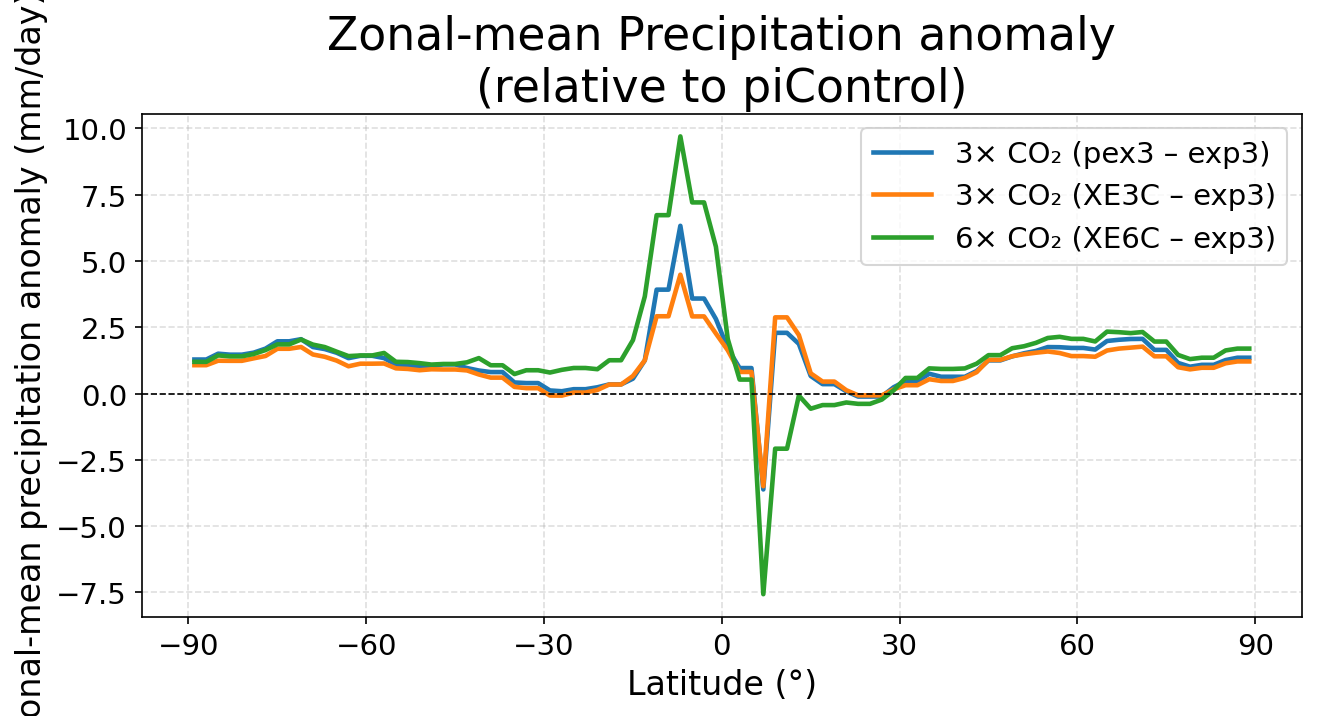

In [112]:
lat = pr_pi_zonal.lat

plt.figure(figsize=(9, 5), dpi=150)

labels = {
    "ex3": "3× CO₂ (pex3 – exp3)",
    "3x": "3× CO₂ (XE3C – exp3)",
    "6x_X": "6× CO₂ (XE6C – exp3)",
}

for k in ["ex3", "3x", "6x_X"]:
    plt.plot(lat, pr_anom_zonal[k], label=labels[k], linewidth=2.2)

plt.axhline(0, color="k", linewidth=0.8, linestyle="--")

plt.xlabel("Latitude (°)", fontsize=16)
plt.ylabel("Zonal-mean precipitation anomaly (mm/day)", fontsize=16)
plt.title(
    "Zonal-mean Precipitation anomaly\n(relative to piControl)",
    fontsize=22
)

plt.xticks(np.arange(-90, 91, 30), fontsize=14)
plt.yticks(fontsize=14)
plt.grid(True, linestyle="--", alpha=0.4)
plt.legend(fontsize=14)
plt.tight_layout()
plt.show()


In [113]:
P = {k: global_mean(pr[k]).values for k in ["pi", "ex3","3x","6x_X"]}

deltaP = {
    k: P[k] - P["pi"]
    for k in ["ex3","3x","6x_X"]
}

print(deltaP)

{'ex3': np.float64(1.1832160641955909), '3x': np.float64(1.0139323911257638), '6x_X': np.float64(1.4491285696686145)}


In [114]:
co2 = np.array([1,3,3,6])
prec = np.array([P["pi"], P["ex3"], P["3x"], P["6x_X"]])

x = np.log2(co2)

slope, intercept = np.polyfit(x, prec, 1)
print (prec)

[2.88800398 4.07122005 3.90193637 4.33713255]


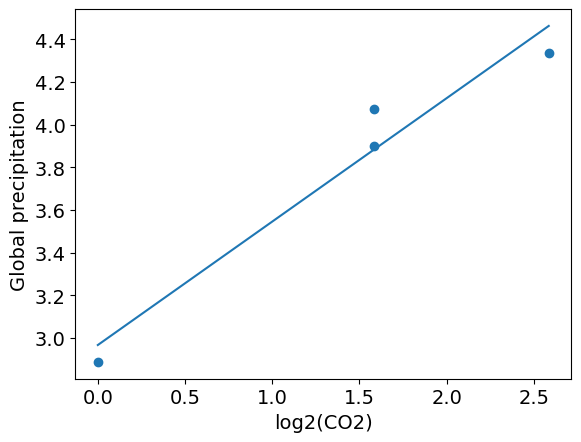

In [115]:
plt.scatter(x, prec)

xfit = np.linspace(0, np.log2(6),100)
plt.plot(xfit, slope*xfit + intercept)

plt.xlabel("log2(CO2)")
plt.ylabel("Global precipitation")
plt.show()

# SSTs

In [116]:
tos = {}

# piControl
tos["pi"] = exp3_oce["tos"]

# perturbation experiments
for k, ds in oce.items():
    tos[k] = ds["tos"]

In [117]:
# --- ANNUAL MEAN (already in °C) ---
tos_annual = {}
# Annual mean SST for all experiments
tos_annual = {k: da.mean("time_counter") for k, da in tos.items()}


In [118]:
tos_pi = tos_annual["pi"]

# --- OCEAN MASK FOR EXP3 (for zonal mean calculation only) ---
ocean_mask_pi = tos_pi.notnull()

# --- LATITUDE WEIGHTS ---
weights = np.cos(np.deg2rad(tos_pi.lat))
weights = weights / weights.mean()

# --- ZONAL MEAN (over exp3 ocean) ---
tos_pi_zonal = (
    tos_pi
    .where(ocean_mask_pi)
    .weighted(weights)
    .mean("lon")
)


In [119]:
# --- BROADCAST ZONAL MEAN TO EACH EXPERIMENT AND MASK THEIR OWN LAND ---
tos_anom = {}

for k in exp_order:
    if k == "piP":
        continue

    tos_pi_2d = (
        tos_pi_zonal
        .broadcast_like(tos_annual[k])
        .where(tos_annual[k].notnull())
    )

    tos_anom[k] = tos_annual[k] - tos_pi_2d

### 4 panels SST anomalies

In [120]:
tos_cyc, lon_cyc = add_cyclic_point(tos_annual["pi"], coord=tos_annual["pi"].lon)

data_cyc = {}
for k in ["ex3", "3x", "6x_X"]:
    data_cyc[k], _ = add_cyclic_point(tos_anom[k].values, coord=tos_anom[k].lon.values)
    


In [121]:
# --- COLOR LEVELS & COLORMAPS ---
levels_abs = np.arange(-5, 40, 6)
levels_anom = np.arange(-30, 30.5, 2)

cmap_abs = cmocean.cm.thermal
cmap_anom = cmocean.cm.balance

norm_abs = mcolors.BoundaryNorm(levels_abs, cmap_abs.N)
norm_anom = mcolors.BoundaryNorm(levels_anom, cmap_anom.N)

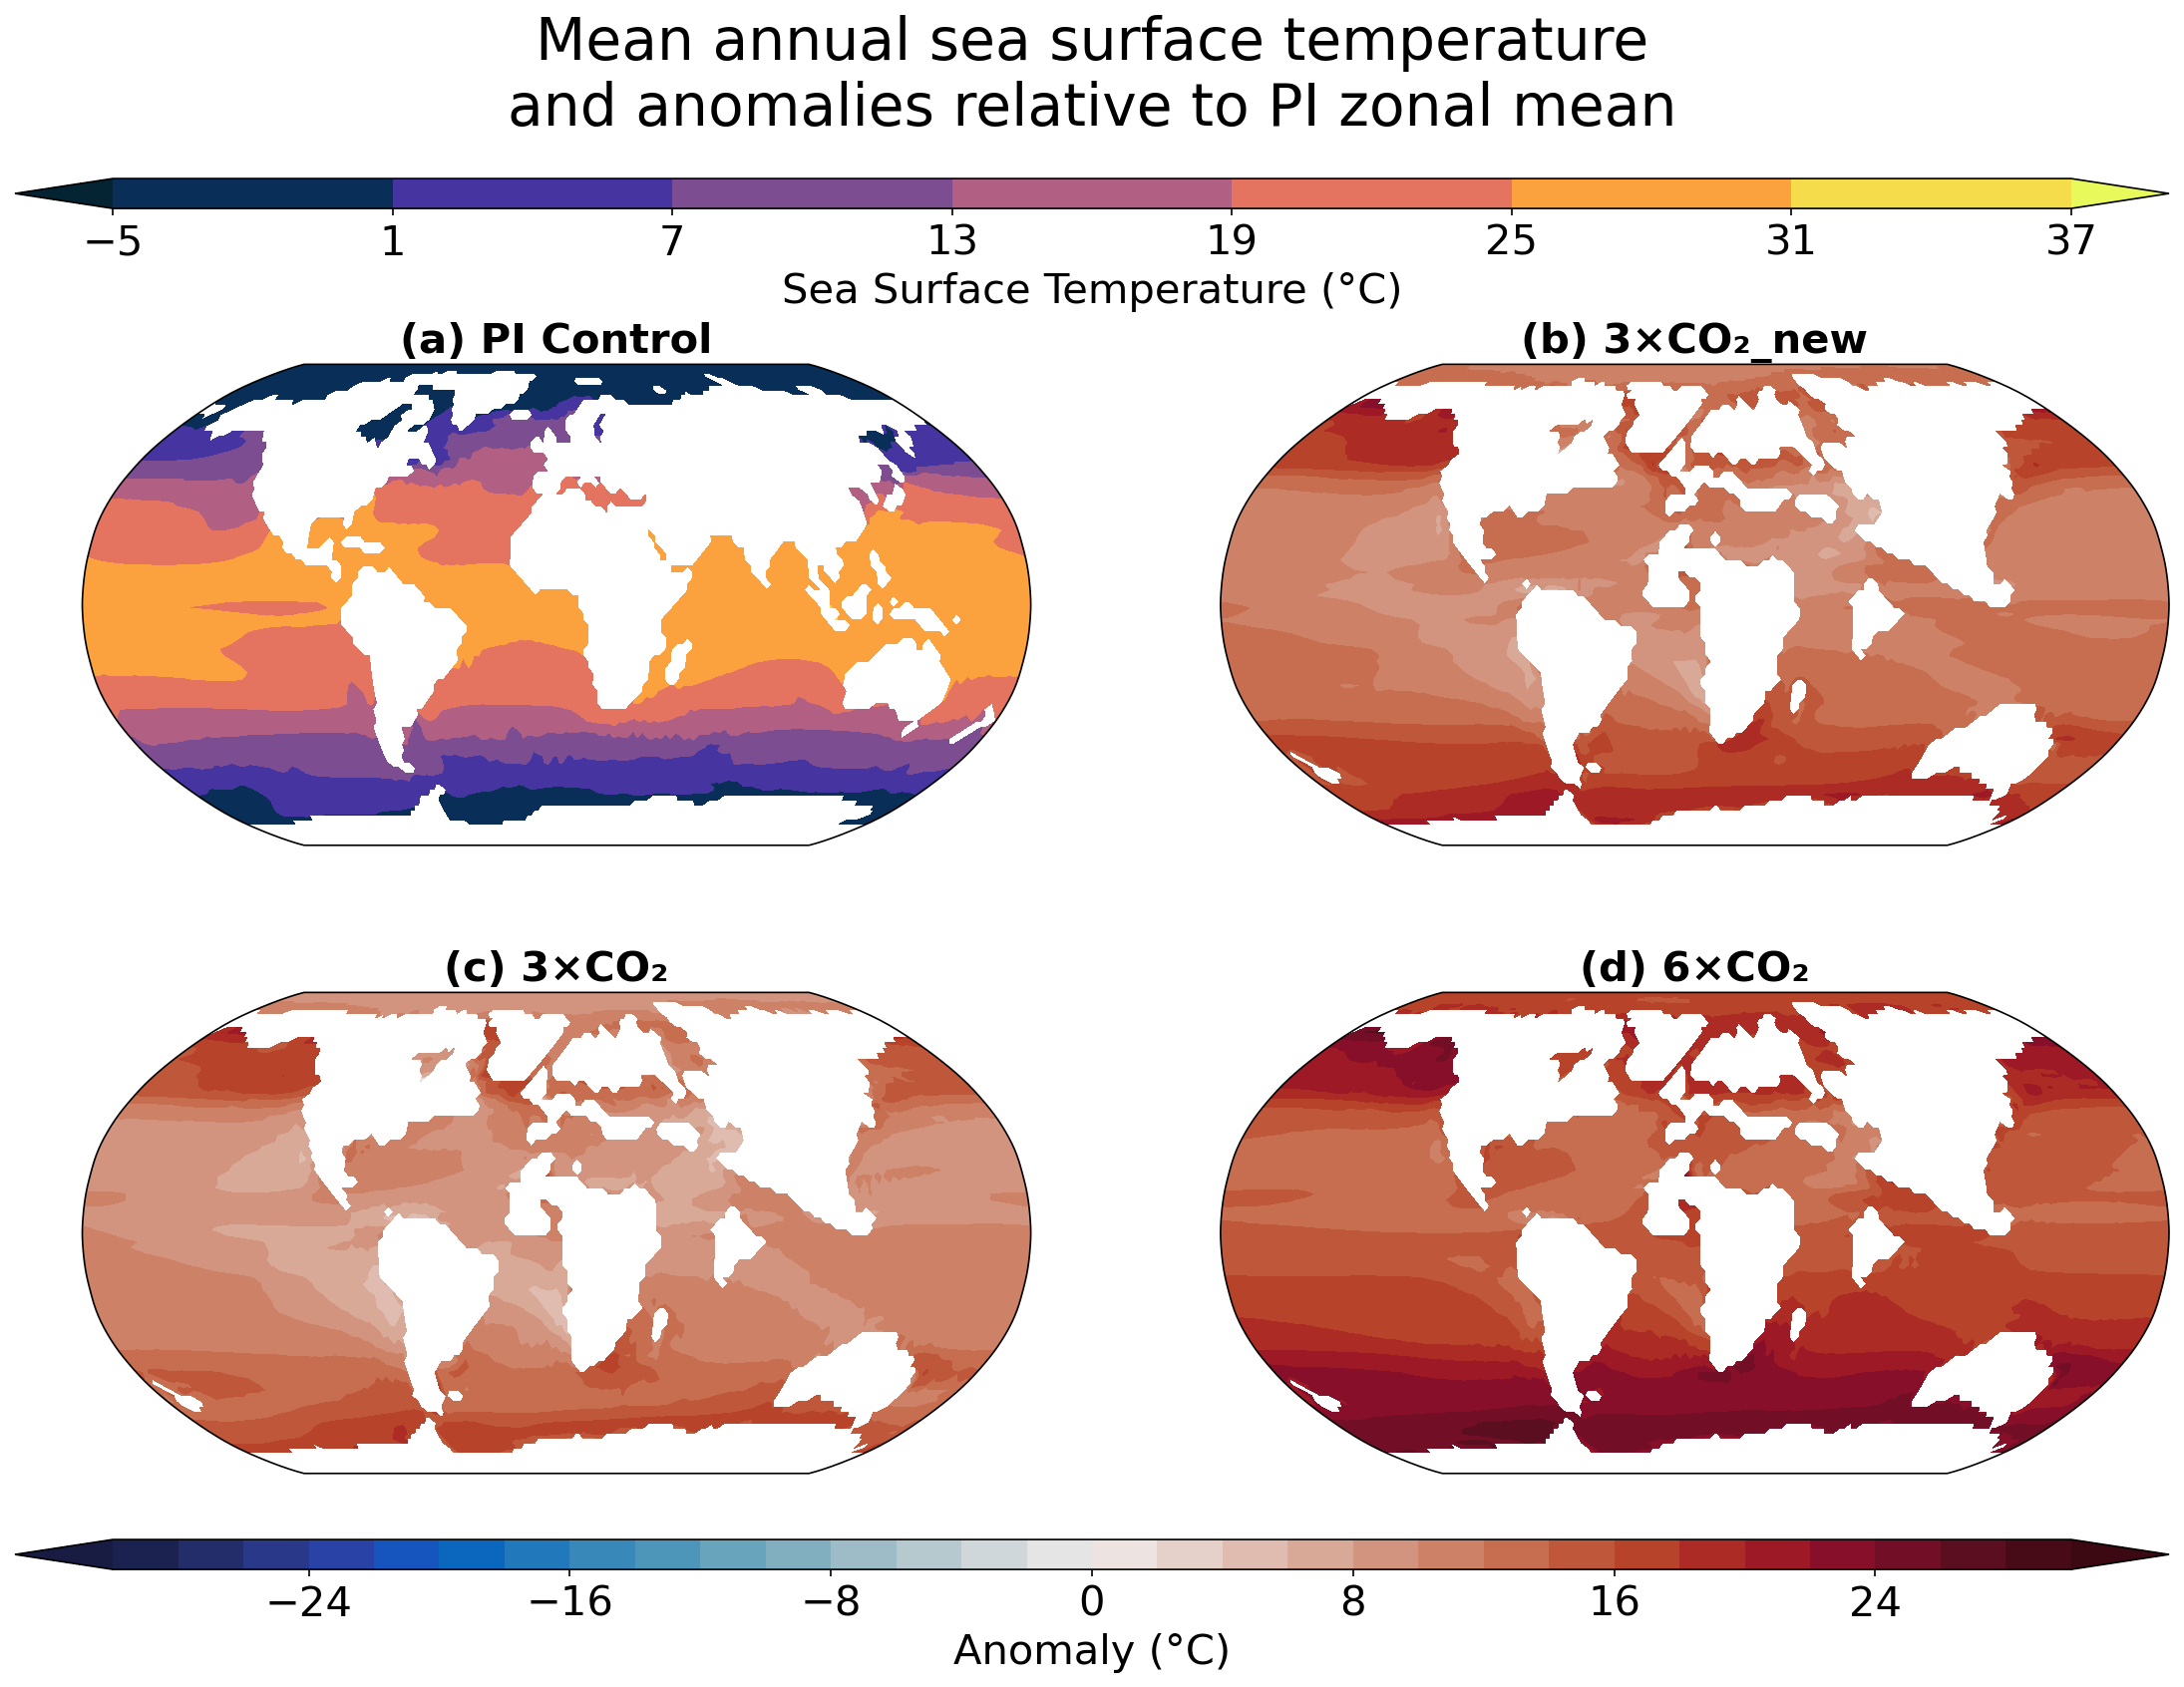

In [122]:
fig, axes = plt.subplots(
    2, 2, figsize=(18, 10), dpi=150,
    subplot_kw={"projection": ccrs.Robinson()}
)
axs = axes.flatten()

cf0 = axs[0].contourf(
    lon_cyc, tos_annual["pi"].lat, tos_cyc,
    levels=levels_abs, cmap=cmap_abs,
    transform=ccrs.PlateCarree(), extend="both"
)
axs[0].set_title("(a) PI Control", fontsize= 20, fontweight="bold")
axs[0].set_global()

titles = {"ex3": "(b) 3×CO₂_new", "3x": "(c) 3×CO₂", "6x_X": "(d) 6×CO₂"}

for i, k in enumerate(["ex3", "3x", "6x_X"], start=1):
    cf = axs[i].contourf(
        lon_cyc, tos_anom[k].lat, data_cyc[k],
        levels=levels_anom, cmap=cmap_anom,
        transform=ccrs.PlateCarree(), extend="both"
    )
    axs[i].set_title(titles[k], fontsize= 20, fontweight="bold")
    axs[i].set_global()


cax_abs = fig.add_axes([0.1, 0.97, 0.8, 0.02])
cbar_abs = fig.colorbar(cf0, cax=cax_abs, orientation="horizontal")
cbar_abs.set_label("Sea Surface Temperature (°C)", fontsize=20)
cbar_abs.ax.tick_params(labelsize=20)

cax_anom = fig.add_axes([0.1, 0.06, 0.8, 0.02])
cbar_anom = fig.colorbar(cf, cax=cax_anom, orientation="horizontal")
cbar_anom.set_label("Anomaly (°C)", fontsize=20)
cbar_anom.ax.tick_params(labelsize=20)


fig.suptitle(
    "Mean annual sea surface temperature\nand anomalies relative to PI zonal mean",
    fontsize= 28,
    y=1.1
)

plt.savefig("tos_maps.png", bbox_inches="tight")
plt.show()

## Global mean surface temperature calculations

In [123]:
TOS = {k: global_mean(v).values for k, v in tos_annual.items()}

In [124]:
TOS["pi"]

array(18.90913882)

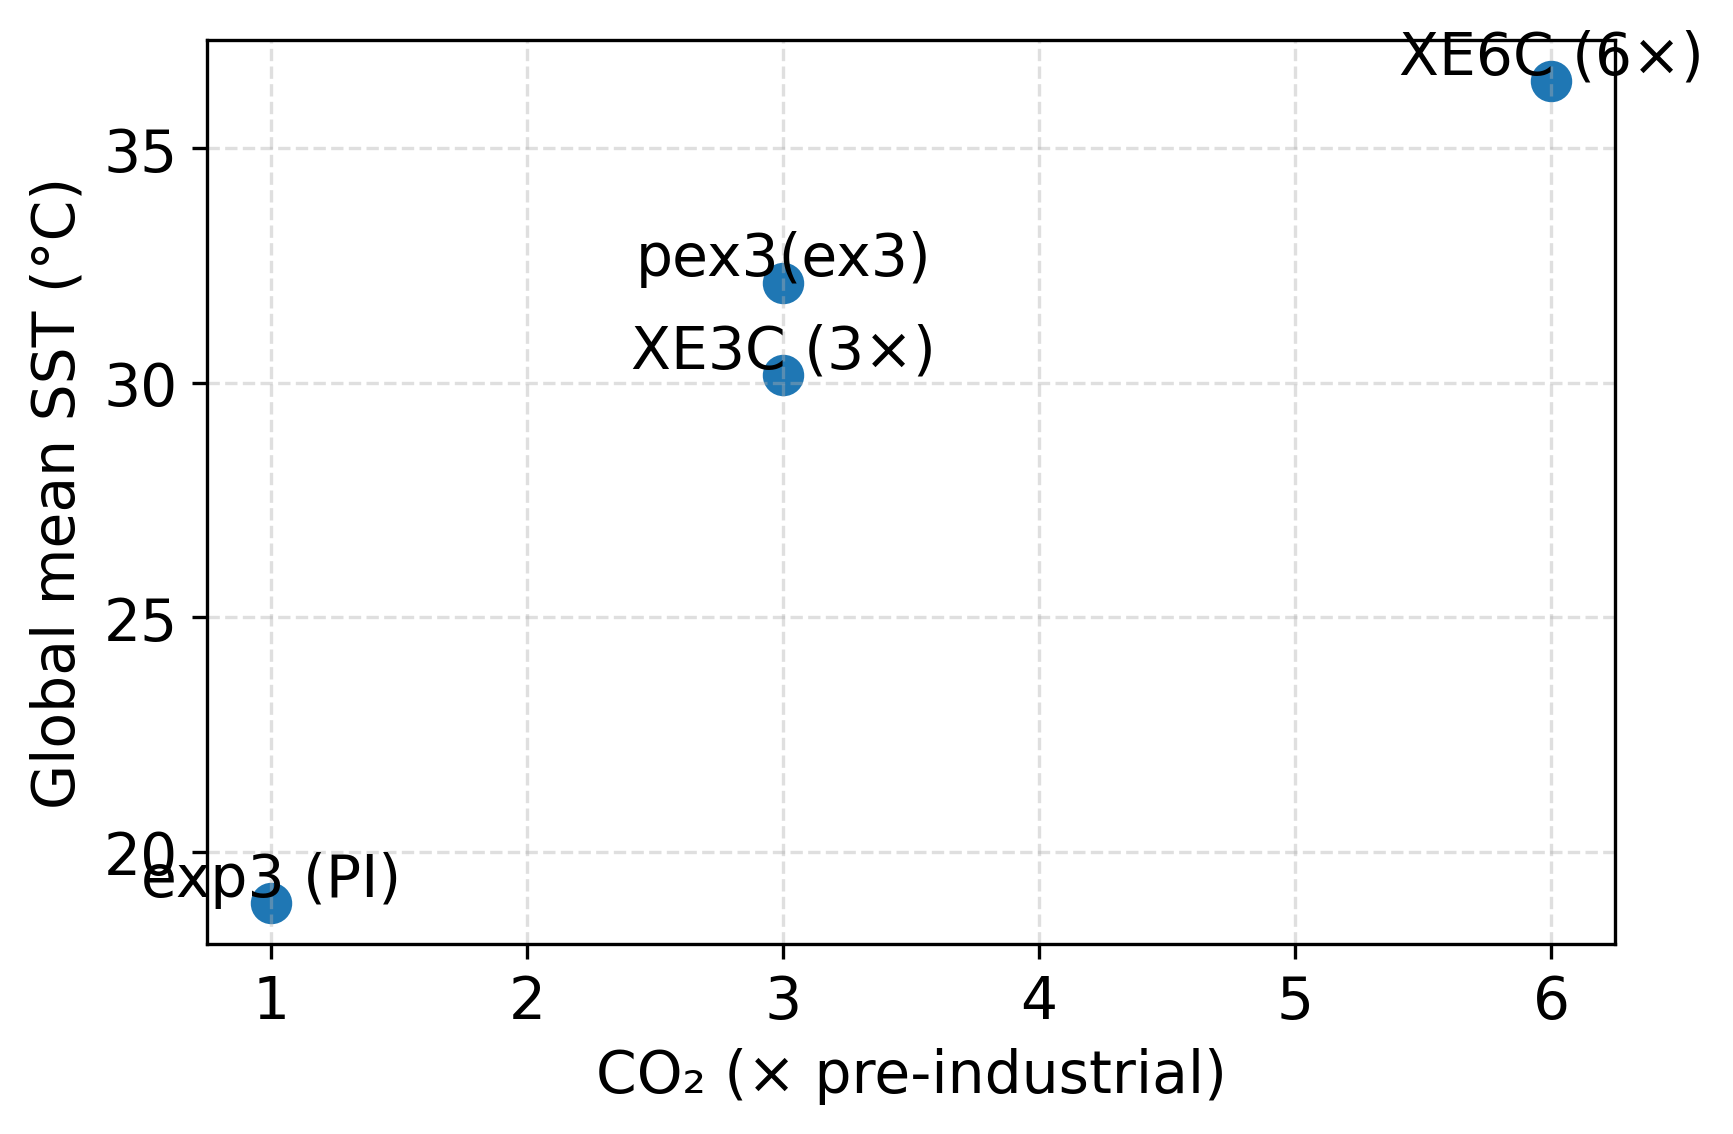

In [125]:
co2 = [1, 3, 3, 6]
labels = ["exp3 (PI)", "pex3(ex3)", "XE3C (3×)", "XE6C (6×)"]
vals = [TOS["pi"], TOS["ex3"], TOS["3x"], TOS["6x_X"]]

plt.figure(figsize=(6, 4), dpi=300)
plt.scatter(co2, vals, s=80)

for x, y, lab in zip(co2, vals, labels):
    plt.text(x, y + 0.15, lab, ha="center")

plt.xlabel("CO₂ (× pre-industrial)")
plt.ylabel("Global mean SST (°C)")
plt.grid(True, linestyle="--", alpha=0.4)
plt.tight_layout()
plt.savefig("tas_global_vs_co2.png")
plt.show()

In [126]:
print("\nCO₂ ×   Global mean SST (°C)")
print("-----------------------------")
print(f"1× (exp3)  : {TOS['pi']:6.2f}")
print(f"3× (pex3)  : {TOS['ex3']:6.2f}")
print(f"3× (XE3C)  : {TOS['3x']:6.2f}")
print(f"6× (XE6C)  : {TOS['6x_X']:6.2f}")


print("\nΔT relative to exp3 (°C)")
print("-------------------------")
print(f"pex3 – exp3 : {TOS['ex3'] - TOS['pi']:+.2f}")
print(f"XE3C – exp3 : {TOS['3x'] - TOS['pi']:+.2f}")
print(f"XE6C – exp3 : {TOS['6x_X'] - TOS['pi']:+.2f}")


CO₂ ×   Global mean SST (°C)
-----------------------------
1× (exp3)  :  18.91
3× (pex3)  :  32.14
3× (XE3C)  :  30.16
6× (XE6C)  :  36.43

ΔT relative to exp3 (°C)
-------------------------
pex3 – exp3 : +13.23
XE3C – exp3 : +11.25
XE6C – exp3 : +17.52


In [127]:
tos_trop = {k: trop_mean_sst(v).values for k, v in tos_annual.items()}

In [128]:
tos_high = {k: high_lat_mean_sst(v).values for k, v in tos_annual.items()}

In [129]:
dT = {k: tos_trop[k] - tos_high[k] for k in tos_annual.keys()}

In [130]:
print("\nCO₂ ×   Global mean SST (°C)")
print("-----------------------------")
print(f"1× (exp3)  : {dT['pi']:6.2f}")
print(f"3× (pex3)  : {dT['ex3']:6.2f}")
print(f"3× (XE3C)  : {dT['3x']:6.2f}")
print(f"6× (XE6C)  : {dT['6x_X']:6.2f}")


print("\nΔT relative to exp3 (°C)")
print("-------------------------")
print(f"pex3 – XPPI : {dT['ex3'] - dT['pi']:+.2f}")
print(f"XE3C – XPPI : {dT['3x'] - dT['pi']:+.2f}")
print(f"XE6C – XPPI : {dT['6x_X'] - dT['pi']:+.2f}")


CO₂ ×   Global mean SST (°C)
-----------------------------
1× (exp3)  :  25.47
3× (pex3)  :  19.80
3× (XE3C)  :  20.66
6× (XE6C)  :  18.22

ΔT relative to exp3 (°C)
-------------------------
pex3 – XPPI : -5.67
XE3C – XPPI : -4.80
XE6C – XPPI : -7.25


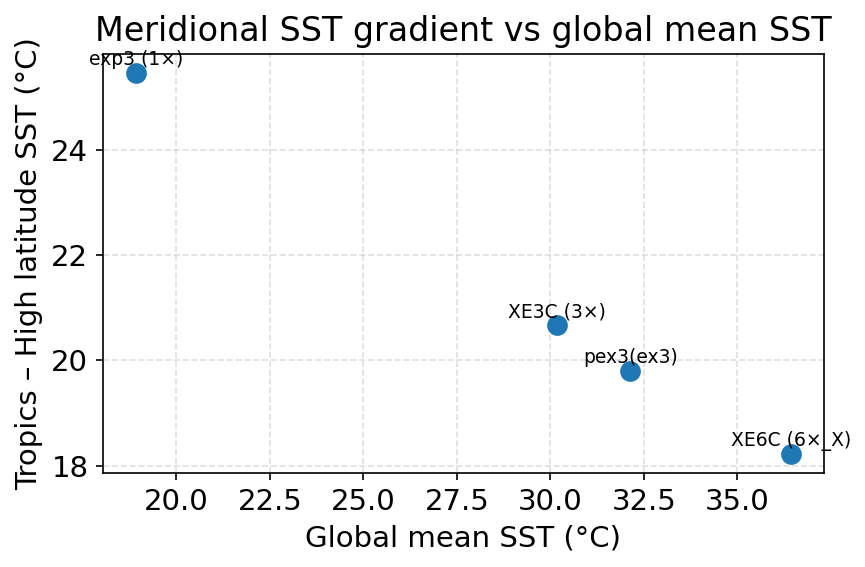

In [131]:
# x-axis: global mean SST
x_sst = np.array([TOS[k] for k in exp_order])

# y-axis: meridional SST gradient
y_grad = np.array([dT[k] for k in exp_order])

labels = ["exp3 (1×)", "pex3(ex3)", "XE3C (3×)", "XE6C (6×_X)"]

plt.figure(figsize=(6, 4), dpi=150)

plt.scatter(x_sst, y_grad, s=80, zorder=3)

# Annotate
for x, y, lab in zip(x_sst, y_grad, labels):
    plt.text(x, y + 0.15, lab, ha="center", fontsize=9)

plt.xlabel("Global mean SST (°C)")
plt.ylabel("Tropics – High latitude SST (°C)")
plt.title("Meridional SST gradient vs global mean SST")

plt.grid(True, linestyle="--", alpha=0.4)
plt.tight_layout()
plt.show()

In [132]:
sos = {}

# piControl
sos["pi"] = exp3_oce["sos"]

# perturbation experiments
for k, ds in oce.items():
    sos[k] = ds["sos"]

In [133]:
# --- ANNUAL MEAN (already in °C) ---
sos_annual = {}
# Annual mean SST for all experiments
sos_annual = {k: da.mean("time_counter") for k, da in sos.items()}

In [134]:
sos_pi = sos_annual["pi"]

# --- OCEAN MASK FOR EXP3 (for zonal mean calculation only) ---
ocean_mask_pi = sos_pi.notnull()

# --- LATITUDE WEIGHTS ---
weights = np.cos(np.deg2rad(sos_pi.lat))
weights = weights / weights.mean()

# --- ZONAL MEAN (over exp3 ocean) ---
sos_pi_zonal = (
    sos_pi
    .where(ocean_mask_pi)
    .weighted(weights)
    .mean("lon")
)


In [135]:
# --- BROADCAST ZONAL MEAN TO EACH EXPERIMENT AND MASK THEIR OWN LAND ---
sos_anom = {}

for k in exp_order:
    if k == "pi":
        continue

    sos_pi_2d = (
        sos_pi_zonal
        .broadcast_like(sos_annual[k])
        .where(sos_annual[k].notnull())
    )

    sos_anom[k] = sos_annual[k] - sos_pi_2d

In [136]:
sos_cyc, son_cyc = add_cyclic_point(sos_annual["pi"], coord=sos_annual["pi"].lon)

data_cyc = {}
for k in ["ex3", "3x", "6x_X"]:
    data_cyc[k], _ = add_cyclic_point(sos_anom[k].values, coord=sos_anom[k].lon.values)

In [137]:
# --- COLOR LEVELS & COLORMAPS ---
levels_abs = np.arange(30.5, 36.5, 0.5)
levels_anom = np.arange(-5, 5.5, 0.5)

cmap_abs = cmocean.cm.haline
cmap_anom = cmocean.cm.balance

norm_abs = mcolors.BoundaryNorm(levels_abs, cmap_abs.N)
norm_anom = mcolors.BoundaryNorm(levels_anom, cmap_anom.N)

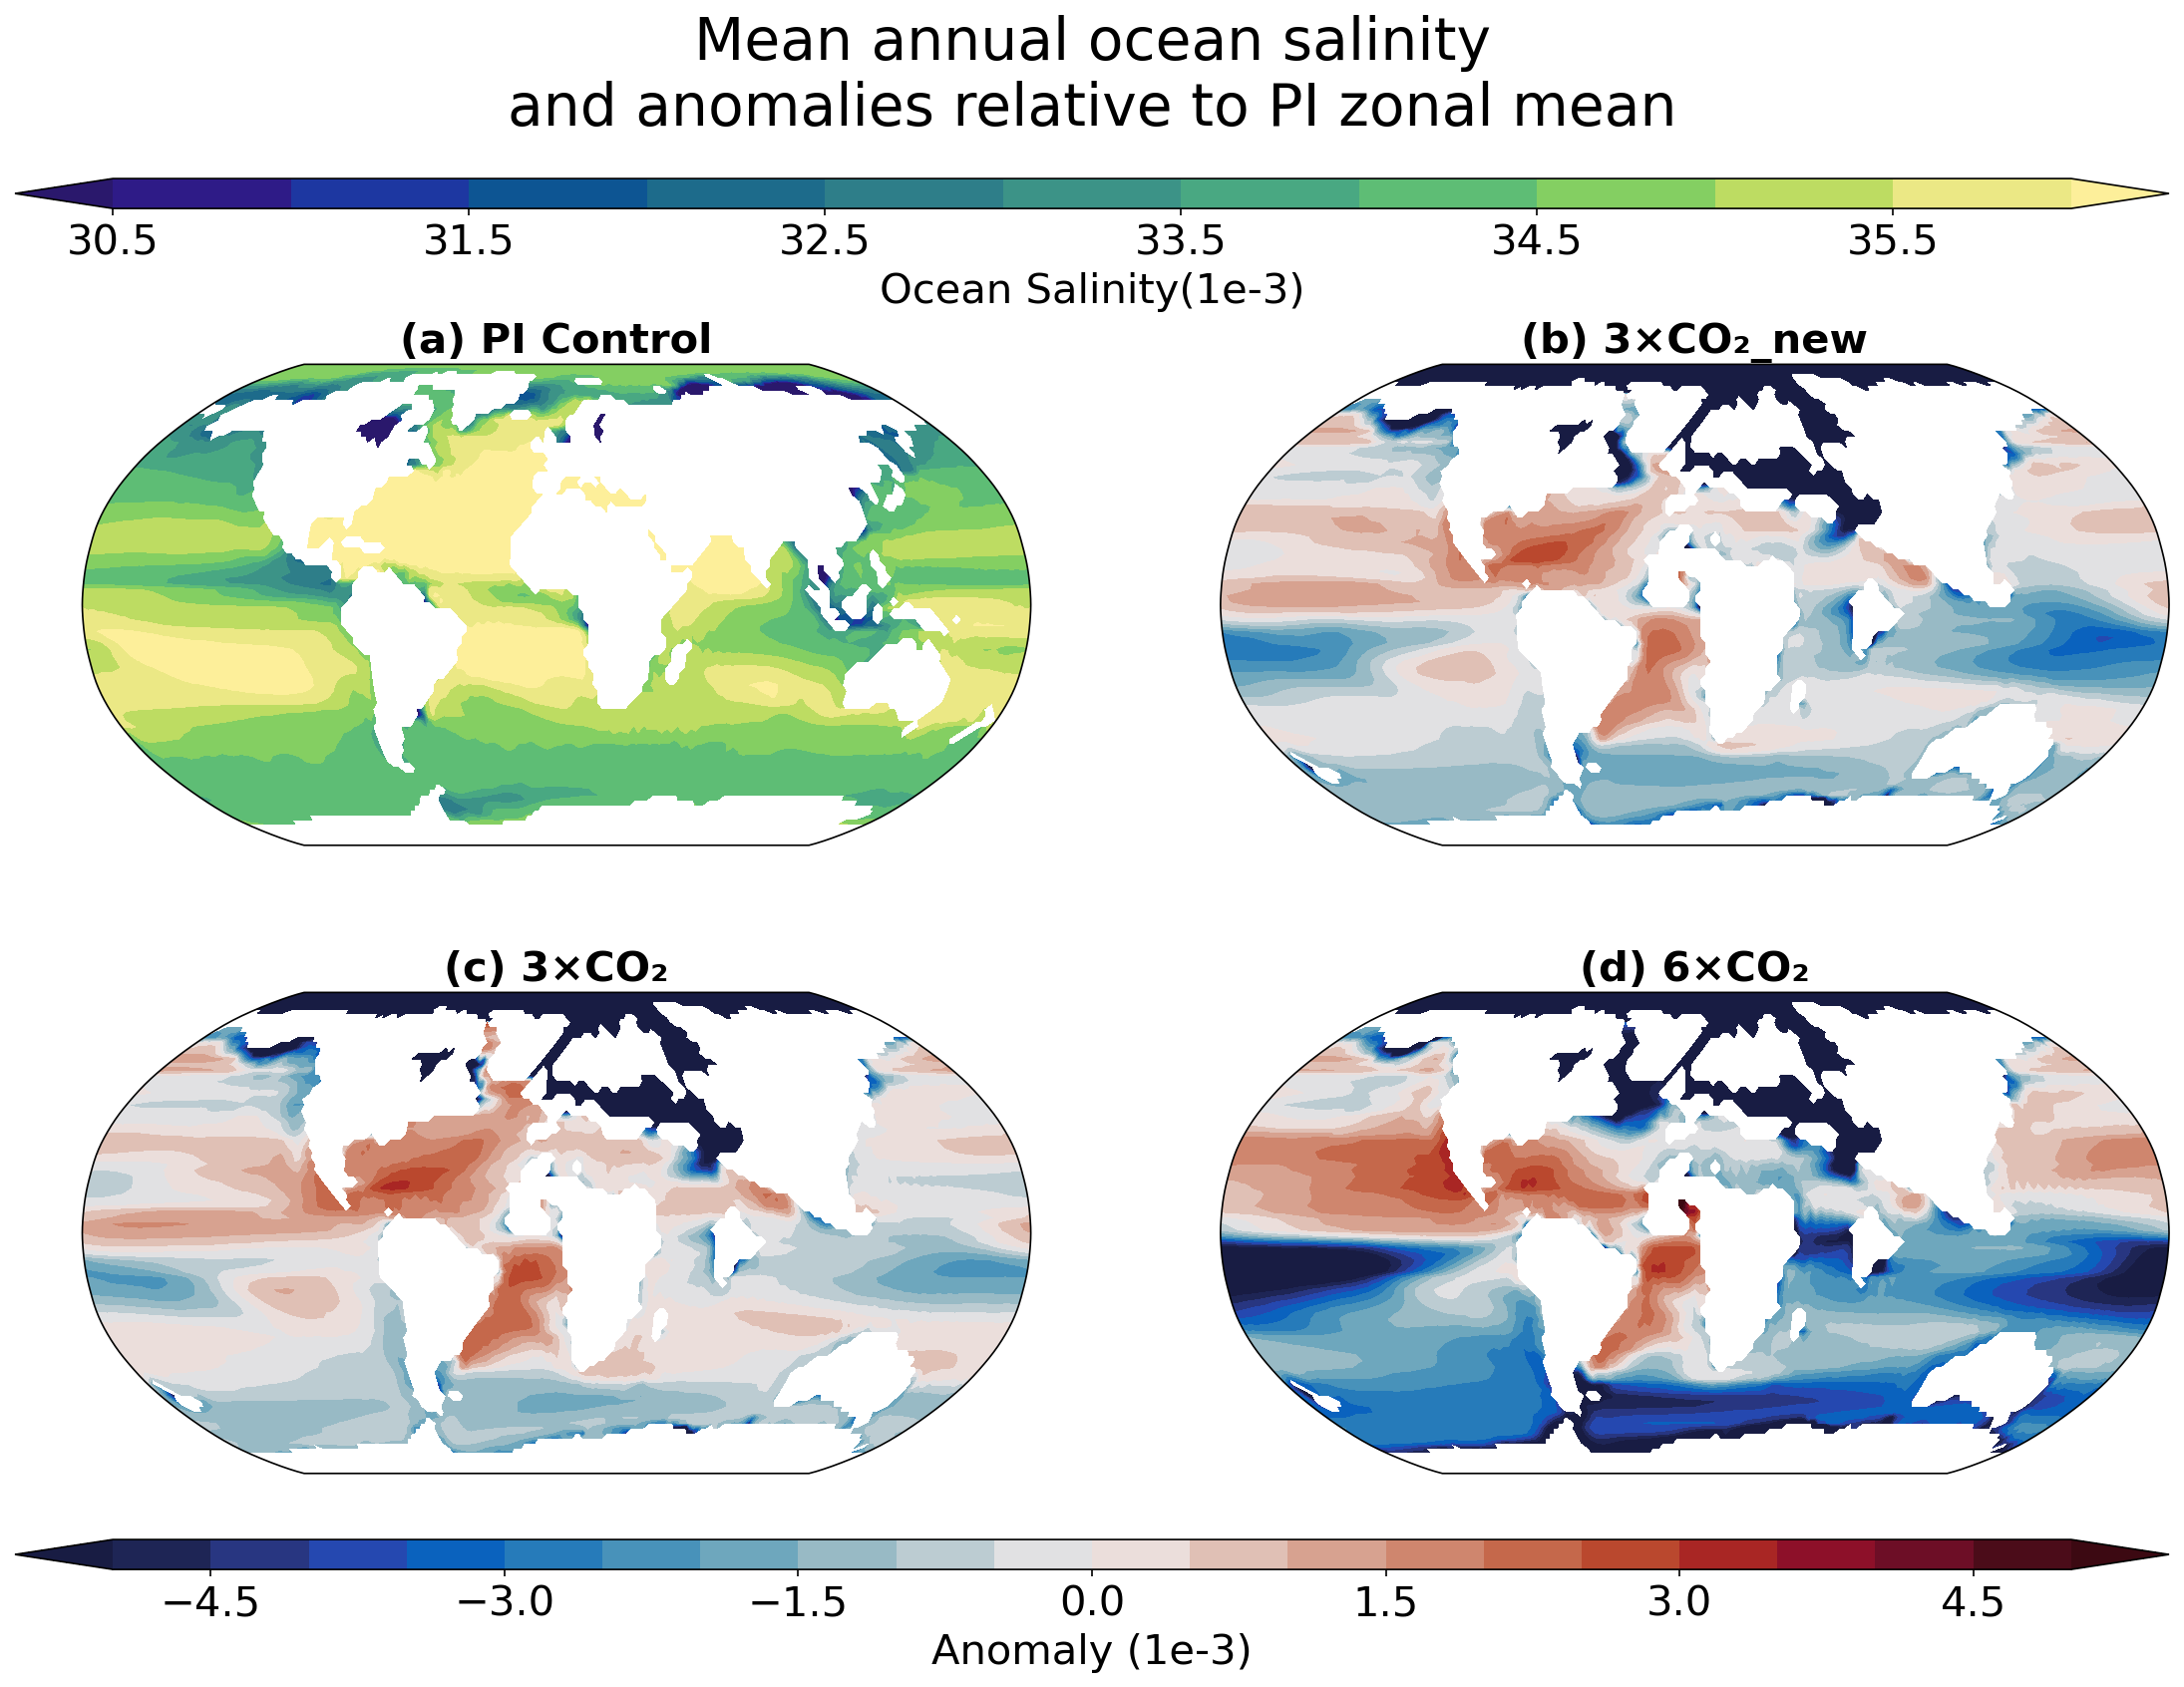

In [138]:
fig, axes = plt.subplots(
    2, 2, figsize=(18, 10), dpi=150,
    subplot_kw={"projection": ccrs.Robinson()}
)
axs = axes.flatten()

cf0 = axs[0].contourf(
    lon_cyc, sos_annual["pi"].lat, sos_cyc,
    levels=levels_abs, cmap=cmap_abs,
    transform=ccrs.PlateCarree(), extend="both"
)
axs[0].set_title("(a) PI Control", fontsize= 20, fontweight="bold")
axs[0].set_global()

titles = {"ex3": "(b) 3×CO₂_new", "3x": "(c) 3×CO₂", "6x_X": "(d) 6×CO₂"}

for i, k in enumerate(["ex3", "3x", "6x_X"], start=1):
    cf = axs[i].contourf(
        lon_cyc, sos_anom[k].lat, data_cyc[k],
        levels=levels_anom, cmap=cmap_anom,
        transform=ccrs.PlateCarree(), extend="both"
    )
    axs[i].set_title(titles[k], fontsize= 20, fontweight="bold")
    axs[i].set_global()


cax_abs = fig.add_axes([0.1, 0.97, 0.8, 0.02])
cbar_abs = fig.colorbar(cf0, cax=cax_abs, orientation="horizontal")
cbar_abs.set_label("Ocean Salinity(1e-3)", fontsize=20)
cbar_abs.ax.tick_params(labelsize=20)

cax_anom = fig.add_axes([0.1, 0.06, 0.8, 0.02])
cbar_anom = fig.colorbar(cf, cax=cax_anom, orientation="horizontal")
cbar_anom.set_label("Anomaly (1e-3)", fontsize=20)
cbar_anom.ax.tick_params(labelsize=20)


fig.suptitle(
    "Mean annual ocean salinity\nand anomalies relative to PI zonal mean",
    fontsize= 28,
    y=1.1
)

plt.savefig("sos_maps.png", bbox_inches="tight")
plt.show()

In [139]:
SOS = {k: global_mean(v).values for k, v in sos_annual.items()}

In [140]:
co2 = [1, 3, 3, 6]
labels = ["exp3 (PI)", "pex(ex3)", "XE3C (3×)", "XE6C (6×_X)"]
vals = [SOS["pi"], SOS["ex3"], SOS["3x"], SOS["6x_X"]]

In [141]:
print("\nCO₂ ×   Global mean SST (°C)")
print("-----------------------------")
#print(f"1× (exp3)  : {SOS['pi']:6.2f}")
print(f"3× (pex3)  : {SOS['ex3']:6.2f}")
print(f"3× (XE3C)  : {SOS['3x']:6.2f}")
print(f"6× (XE6C)  : {SOS['6x_X']:6.2f}")


print("\nΔT relative to exp3 (°C)")
print("-------------------------")
print(f"pex3 – exp3 : {SOS['ex3'] - SOS['pi']:+.2f}")
print(f"XE3C – exp3 : {SOS['3x'] - SOS['pi']:+.2f}")
print(f"XE6C – exp3 : {SOS['6x_X'] - SOS['pi']:+.2f}")


CO₂ ×   Global mean SST (°C)
-----------------------------
3× (pex3)  :  33.89
3× (XE3C)  :  34.04
6× (XE6C)  :  32.67

ΔT relative to exp3 (°C)
-------------------------
pex3 – exp3 : -1.06
XE3C – exp3 : -0.91
XE6C – exp3 : -2.28


# DeepMIP Comparisons

# TAS

In [142]:
models_tas = {
    "CESM": {
        "pi":  "DeepMIP/CESM1.2_CAM5-piControl-tas-v1.0.mean_um_2020-11-19.nc",
        "1x":  "DeepMIP/CESM1.2_CAM5-deepmip_sens_1xCO2-tas-v1.0.mean_um_2020-11-19.nc",
        "3x":  "DeepMIP/CESM1.2_CAM5-deepmip_stand_3xCO2-tas-v1.0.mean_um_2020-11-19.nc",
        "6x":  "DeepMIP/CESM1.2_CAM5-deepmip_stand_6xCO2-tas-v1.0.mean_um_2020-11-19.nc",
        "9x":  "DeepMIP/CESM1.2_CAM5-deepmip_sens_9xCO2-tas-v1.0.mean_um_2020-11-19.nc",
    },

    "COSMOS": {
        "pi":  "DeepMIP/COSMOS-landveg_r2413-piControl-tas-v1.0.mean_um_2020-11-19.nc",
        "1x":  "DeepMIP/COSMOS-landveg_r2413-deepmip_sens_1xCO2-tas-v1.0.mean_um_2020-11-19.nc",
        "3x":  "DeepMIP/COSMOS-landveg_r2413-deepmip_stand_3xCO2-tas-v1.0.mean_um_2020-11-19.nc",
        "4x":  "DeepMIP/COSMOS-landveg_r2413-deepmip_sens_4xCO2-tas-v1.0.mean_um_2020-11-19.nc",
    },

    "GFDL": {
        "pi":  "DeepMIP/GFDL_CM2.1-piControl-tas-v1.0.mean_um_2020-11-19.nc",
        "1x":  "DeepMIP/GFDL_CM2.1-deepmip_sens_1xCO2-tas-v1.0.mean_um_2020-11-19.nc",
        "2x":  "DeepMIP/GFDL_CM2.1-deepmip_sens_2xCO2-tas-v1.0.mean_um_2020-11-19.nc",
        "3x":  "DeepMIP/GFDL_CM2.1-deepmip_stand_3xCO2-tas-v1.0.mean_um_2020-11-19.nc",
        "4x":  "DeepMIP/GFDL_CM2.1-deepmip_sens_4xCO2-tas-v1.0.mean_um_2020-11-19.nc",
        "6x":  "DeepMIP/GFDL_CM2.1-deepmip_stand_6xCO2-tas-v1.0.mean_um_2020-11-19.nc",
    },

    "HadCM": {
        "pi": "DeepMIP/HadCM3B_M2.1aN-piControl-tas-v1.0.mean_um_2020-11-19.nc",
        "1x": "DeepMIP/HadCM3B_M2.1aN-deepmip_sens_1xCO2-tas-v1.0.mean_um_2020-11-19.nc",
        "2x": "DeepMIP/HadCM3B_M2.1aN-deepmip_sens_2xCO2-tas-v1.0.mean_um_2020-11-19.nc",
        "3x": "DeepMIP/HadCM3B_M2.1aN-deepmip_stand_3xCO2-tas-v1.0.mean_um_2020-11-19.nc",
    },

    "INM": {
        "pi": "DeepMIP/INM-CM4-8-piControl-tas-v1.0.mean_um_2020-11-19.nc",
        "6x": "DeepMIP/INM-CM4-8-deepmip_stand_6xCO2-tas-v1.0.mean_um_2020-11-19.nc",
    },

    "IPSL": {
        "pi": "DeepMIP/IPSLCM5A2-piControl-tas-v1.0.mean_um_2020-11-19.nc",
        "1.5x": "DeepMIP/IPSLCM5A2-deepmip_sens_1.5xCO2-tas-v1.0.mean_um_2020-11-19.nc",
        "3x": "DeepMIP/IPSLCM5A2-deepmip_stand_3xCO2-tas-v1.0.mean_um_2020-11-19.nc",
    },

    "MIROC": {
        "pi": "DeepMIP/MIROC4m-piControl-tas-v1.0.mean_um_2020-11-19.nc",
        "3x": "DeepMIP/MIROC4m-deepmip_stand_3xCO2-tas-v1.0.mean_um_2020-11-19.nc",
    },

    "NorESM": {
        "pi": "DeepMIP/NorESM1_F-piControl-tas-v1.0.mean_um_2020-11-19.nc",
        "2x": "DeepMIP/NorESM1_F-deepmip_sens_2xCO2-tas-v1.0.mean_um_2020-11-19.nc",
        "4x": "DeepMIP/NorESM1_F-deepmip_sens_4xCO2-tas-v1.0.mean_um_2020-11-19.nc",
    }
} 

In [143]:
results = {}

for model, experiments in models_tas.items():
    results[model] = {}

    for exp, filename in experiments.items():
        path = base_path / filename  # <-- use / to join Path + string

        ds = xr.open_mfdataset(path, combine="by_coords", decode_times=False)
        gm = global_mean_tas(ds)

        results[model][exp] = gm

    print(f"\n{model} global TAS")
    print("-" * 25)
    for exp, value in results[model].items():
        print(f"{exp:>3} : {value:.2f}")


CESM global TAS
-------------------------
 pi : 13.23
 1x : 18.36
 3x : 24.99
 6x : 29.77
 9x : 35.47

COSMOS global TAS
-------------------------
 pi : 13.87
 1x : 16.97
 3x : 25.19
 4x : 26.91

GFDL global TAS
-------------------------
 pi : 15.63
 1x : 19.24
 2x : 22.91
 3x : 25.37
 4x : 27.49
 6x : 30.23

HadCM global TAS
-------------------------
 pi : 13.93
 1x : 17.44
 2x : 21.20
 3x : 25.05

INM global TAS
-------------------------
 pi : 13.23
 6x : 23.38

IPSL global TAS
-------------------------
 pi : 13.19
1.5x : 19.42
 3x : 24.97

MIROC global TAS
-------------------------
 pi : 12.89
 3x : 23.51

NorESM global TAS
-------------------------
 pi : 14.47
 2x : 21.23
 4x : 24.09


In [144]:
co2_map = {
    "pi": 1,
    "1x": 1,
    "1.5x": 1.5,
    "2x": 2,
    "3x": 3,
    "4x": 4,
    "6x": 6,
    "9x": 9,
}

data = []

for model, exps in results.items():
    for exp, temp in exps.items():

        data.append({
            "model": model,
            "CO2": co2_map.get(exp, None),
            "T": temp,
            "pi": exp == "pi"
        })

In [145]:
ec_earth_map = {
    "pi": 1,
#    "piP": 1,   # still 1× CO2
#    "1x": 1,
    "ex3": 3,
    "3x": 3,
    "6x_X": 6,
}

for exp, temp in T.items():
    data.append({
        "model": "EC-EARTH4",
        "CO2": ec_earth_map[exp],
        "T": temp,
        "pi": exp == "pi"  # only true PI small
    })

In [146]:
# Unique models
models = list(set(d["model"] for d in data))
colors = plt.cm.tab10.colors  # 10 distinct colors
model_styles = {
    "IPSL":     {"color": "lightblue", "marker": "D"},  # diamond
    "GFDL":     {"color": "orange",    "marker": "o"},  # circle
    "CESM":     {"color": "blue",      "marker": "s"},  # square
    "INM":      {"color": "purple",    "marker": "*"},  # star
    "COSMOS":   {"color": "brown",     "marker": "^"},  # triangle_up
    "HadCM":    {"color": "yellow",    "marker": "v"},  # triangle_down
    "MIROC":    {"color": "red",       "marker": "^"},  # triangle_up
    "NorESM":   {"color": "pink",      "marker": "v"},  # triangle_down
    "EC-EARTH4":{"color": "green",     "marker": "X"},  # cross
}

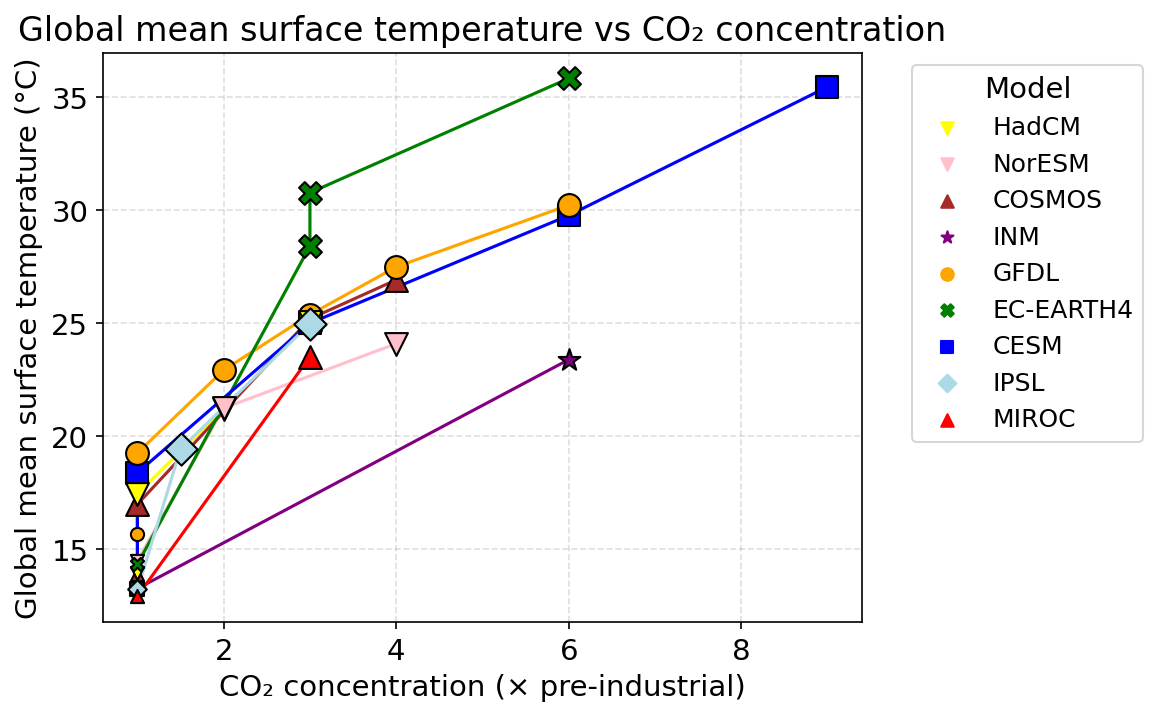

In [147]:
plt.figure(figsize=(8,5), dpi=150)

for d in data:
    m = d["model"]
    style = model_styles[m]
    # smaller size for piControl points only
    size = 40 if d.get("pi", False) else 120
    plt.scatter(
        d["CO2"],
        d["T"],
        color=style["color"],
        marker=style["marker"],
        s=size,
        edgecolor='k',
        zorder=3
    )

for m in models:
    style = model_styles[m]

    xs = [d["CO2"] for d in data if d["model"] == m]
    ys = [d["T"]   for d in data if d["model"] == m]

    order = np.argsort(xs)
    xs = np.array(xs)[order]
    ys = np.array(ys)[order]

    plt.plot(xs, ys, color=style["color"], linewidth=1.5, zorder=2)

plt.xlabel("CO₂ concentration (× pre-industrial)")
plt.ylabel("Global mean surface temperature (°C)")
plt.title("Global mean surface temperature vs CO₂ concentration")
plt.grid(True, alpha=0.4, linestyle="--")

# Create legend manually
for m in models:
    plt.scatter([], [], color=model_styles[m]["color"], marker=model_styles[m]["marker"], label=m)
plt.legend(title="Model", bbox_to_anchor=(1.05,1), loc="upper left")

plt.tight_layout()
plt.show()

# SST

In [68]:
models_sst = {
    "CESM": {
        "pi":  "DeepMIP/CESM1.2_CAM5-piControl-tos-v1.0.mean_um_sst_nn_2020-11-19.nc",
        "1x":  "DeepMIP/CESM1.2_CAM5-deepmip_sens_1xCO2-tos-v1.0.mean_um_sst_nn_2020-11-19.nc",
        "3x":  "DeepMIP/CESM1.2_CAM5-deepmip_stand_3xCO2-tos-v1.0.mean_um_sst_nn_2020-11-19.nc",
        "6x":  "DeepMIP/CESM1.2_CAM5-deepmip_stand_6xCO2-tos-v1.0.mean_um_sst_nn_2020-11-19.nc",
        "9x":  "DeepMIP/CESM1.2_CAM5-deepmip_sens_9xCO2-tos-v1.0.mean_um_sst_nn_2020-11-19.nc",
    },

    "COSMOS": {
        "pi":  "DeepMIP/COSMOS-landveg_r2413-piControl-tos-v1.0.mean_um_sst_nn_2020-11-19.nc",
        "1x":  "DeepMIP/COSMOS-landveg_r2413-deepmip_sens_1xCO2-tos-v1.0.mean_um_sst_nn_2020-11-19.nc",
        "3x":  "DeepMIP/COSMOS-landveg_r2413-deepmip_stand_3xCO2-tos-v1.0.mean_um_sst_nn_2020-11-19.nc",
        "4x":  "DeepMIP/COSMOS-landveg_r2413-deepmip_sens_4xCO2-tos-v1.0.mean_um_sst_nn_2020-11-19.nc",
    },

    "GFDL": {
        "pi":  "DeepMIP/GFDL_CM2.1-piControl-tos-v1.0.mean_um_sst_nn_2020-11-19.nc",
        "1x":  "DeepMIP/GFDL_CM2.1-deepmip_sens_1xCO2-tos-v1.0.mean_um_sst_nn_2020-11-19.nc",
        "2x":  "DeepMIP/GFDL_CM2.1-deepmip_sens_2xCO2-tos-v1.0.mean_um_sst_nn_2020-11-19.nc",
        "3x":  "DeepMIP/GFDL_CM2.1-deepmip_stand_3xCO2-tos-v1.0.mean_um_sst_nn_2020-11-19.nc",
        "4x":  "DeepMIP/GFDL_CM2.1-deepmip_sens_4xCO2-tos-v1.0.mean_um_sst_nn_2020-11-19.nc",
        "6x":  "DeepMIP/GFDL_CM2.1-deepmip_stand_6xCO2-tos-v1.0.mean_um_sst_nn_2020-11-19.nc",
    },

    "HadCM": {
        "pi": "DeepMIP/HadCM3B_M2.1aN-piControl-tos-v1.0.mean_um_sst_nn_2020-11-19.nc",
        "1x": "DeepMIP/HadCM3B_M2.1aN-deepmip_sens_1xCO2-tos-v1.0.mean_um_sst_nn_2020-11-19.nc",
        "2x": "DeepMIP/HadCM3B_M2.1aN-deepmip_sens_2xCO2-tos-v1.0.mean_um_sst_nn_2020-11-19.nc",
        "3x": "DeepMIP/HadCM3B_M2.1aN-deepmip_stand_3xCO2-tos-v1.0.mean_um_sst_nn_2020-11-19.nc",
    },

    "INM": {
        "pi": "DeepMIP/INM-CM4-8-piControl-tos-v1.0.mean_um_sst_nn_2020-11-19.nc",
        "6x": "DeepMIP/INM-CM4-8-deepmip_stand_6xCO2-tos-v1.0.mean_um_sst_nn_2020-11-19.nc",
    },

    "IPSL": {
        "pi": "DeepMIP/IPSLCM5A2-piControl-tos-v1.0.mean_um_sst_nn_2020-11-19.nc",
        "1.5x": "DeepMIP/IPSLCM5A2-deepmip_sens_1.5xCO2-tos-v1.0.mean_um_sst_nn_2020-11-19.nc",
        "3x": "DeepMIP/IPSLCM5A2-deepmip_stand_3xCO2-tos-v1.0.mean_um_sst_nn_2020-11-19.nc",
    },

    "MIROC": {
        "pi": "DeepMIP/MIROC4m-piControl-tos-v1.0.mean_um_sst_nn_2020-11-19.nc",
        "3x": "DeepMIP/MIROC4m-deepmip_stand_3xCO2-tos-v1.0.mean_um_sst_nn_2020-11-19.nc",
    },

    "NorESM": {
        "pi": "DeepMIP/NorESM1_F-piControl-tos-v1.0.mean_um_sst_nn_2020-11-19.nc",
        "2x": "DeepMIP/NorESM1_F-deepmip_sens_2xCO2-tos-v1.0.mean_um_sst_nn_2020-11-19.nc",
        "4x": "DeepMIP/NorESM1_F-deepmip_sens_4xCO2-tos-v1.0.mean_um_sst_nn_2020-11-19.nc",
    }
} 

In [69]:
data = []

for model, experiments in models_sst.items():

    for exp, filename in experiments.items():

        path = base_path / filename
        ds = xr.open_mfdataset(path, combine="by_coords", decode_times=False)

        # ---- global mean ----
        gm_sst = global_mean_sst(ds).compute().item()

        # ---- regional means ----
        trop = regional_mean_sst(ds, -31, 31).compute().item()

        north = regional_mean_sst(ds, 60.01, 90.01).compute().item()
        south = regional_mean_sst(ds, -90.01, -60.01).compute().item()
        high = 0.5 * (north + south)

        grad = trop - high

        data.append({
            "model": model,
            "x": gm_sst,
            "y": grad,
            "exp": exp,
            "pi": exp == "pi"
        })

In [70]:
ec_earth_data = [
    ("pi",  TOS["pi"], dT["pi"]),
    ("piP",  TOS["piP"],   dT["piP"]),
    ("1x",  TOS["1x"],   dT["1x"]),
    ("3x",  TOS["3x"],   dT["3x"]),
    ("6x",  TOS["6x"],   dT["6x"]),
]

for exp, x, y in ec_earth_data:
    data.append({
        "model": "EC-EARTH4",
        "x": float(x),
        "y": float(y),
        "exp": exp,
        "pi": exp == "pi"
    })



In [71]:
models = sorted(set(d["model"] for d in data))

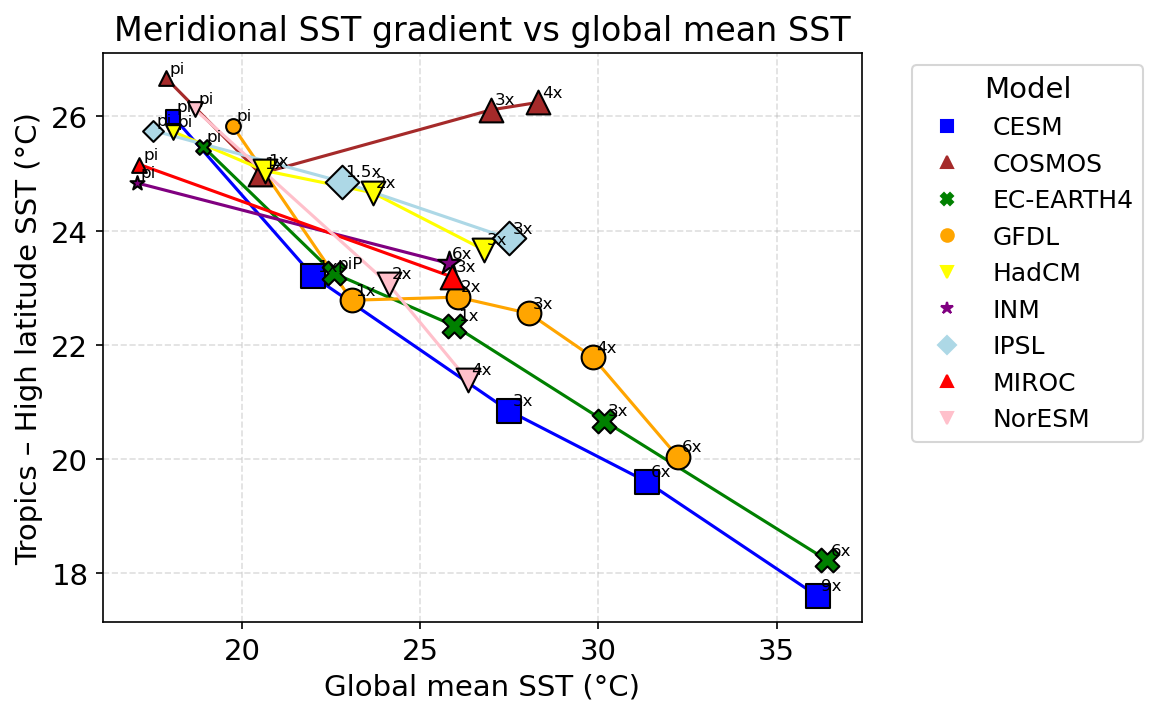

In [72]:
plt.figure(figsize=(8, 5), dpi=150)

# ------------------------------------------------------
# Scatter points
# ------------------------------------------------------
for d in data:
    style = model_styles[d["model"]]
    size = 50 if d["pi"] else 130

    x = float(d["x"])
    y = float(d["y"])

    plt.scatter(
        x, y,
        color=style["color"],
        marker=style["marker"],
        s=size,
        edgecolor="k",
        zorder=3
    )

    plt.text(
        x + 0.1,
        y + 0.1,
        d["exp"],
        fontsize=8,
        zorder=4
    )

# ------------------------------------------------------
# Connecting lines (sorted by SST)
# ------------------------------------------------------
for m in models:
    style = model_styles[m]

    model_points = [d for d in data if d["model"] == m]

    xs = np.array([float(d["x"]) for d in model_points])
    ys = np.array([float(d["y"]) for d in model_points])

    order = np.argsort(xs)

    plt.plot(
        xs[order],
        ys[order],
        color=style["color"],
        linewidth=1.5,
        zorder=2
    )

# ------------------------------------------------------
# Labels
# ------------------------------------------------------
plt.xlabel("Global mean SST (°C)")
plt.ylabel("Tropics – High latitude SST (°C)")
plt.title("Meridional SST gradient vs global mean SST")

plt.grid(True, linestyle="--", alpha=0.4)

# ------------------------------------------------------
# Legend (no duplicates)
# ------------------------------------------------------
handles = []
for m in models:
    handles.append(
        plt.Line2D(
            [], [], 
            color=model_styles[m]["color"],
            marker=model_styles[m]["marker"],
            linestyle="None",
            label=m
        )
    )

plt.legend(
    handles=handles,
    title="Model",
    bbox_to_anchor=(1.05, 1),
    loc="upper left"
)

plt.tight_layout()
plt.show()

In [73]:
print("Model | Experiment | Global mean SST (°C) | Tropics – High lat SST (°C)")
print("-" * 65)

for d in data:
    model = d["model"]
    exp = d["exp"]
    gm_sst = d["x"]
    grad = d["y"]

    print(f"{model:7} | {exp:6} | {gm_sst:8.3f}           | {grad:8.3f}")


Model | Experiment | Global mean SST (°C) | Tropics – High lat SST (°C)
-----------------------------------------------------------------
CESM    | pi     |   18.055           |   25.999
CESM    | 1x     |   21.996           |   23.196
CESM    | 3x     |   27.483           |   20.842
CESM    | 6x     |   31.358           |   19.598
CESM    | 9x     |   36.154           |   17.593
COSMOS  | pi     |   17.864           |   26.668
COSMOS  | 1x     |   20.502           |   24.999
COSMOS  | 3x     |   26.994           |   26.117
COSMOS  | 4x     |   28.315           |   26.248
GFDL    | pi     |   19.733           |   25.831
GFDL    | 1x     |   23.067           |   22.780
GFDL    | 2x     |   26.047           |   22.834
GFDL    | 3x     |   28.055           |   22.548
GFDL    | 4x     |   29.838           |   21.781
GFDL    | 6x     |   32.236           |   20.029
HadCM   | pi     |   18.067           |   25.733
HadCM   | 1x     |   20.625           |   25.052
HadCM   | 2x     |   23.656  